In [41]:
import pandas as pd
import joblib
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore') # Ukrywa ostrzeżenia o wersjach bibliotek

# 1. Wczytanie ustandaryzowanych danych testowych
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')['target']

# 2. Lista modeli do wczytania wraz z ich ścieżkami
model_files = {
    "Naiwny Bayes": "../models/naive_bayes_gaussian_cv.pkl",
    "Regresja Logistyczna": "../models/logistic_regression_cv.pkl",
    "K-NN": "../models/k-nn_cv.pkl",
    "Random Forest": "../models/random_forest_cv.pkl",
    "Random Forest (Zoptymalizowany)": "../models/random_forest_tuned_specificity.pkl",
    "XGBoost": "../models/xgboost_cv.pkl",
    "XGBoost (Zoptymalizowany)": "../models/xgboost_tuned.pkl",
    "LightGBM (Baza)": "../models/lightgbm_cv.pkl",
    "SVM (Linear)": "../models/svm_linear_cv.pkl",
    "SVM (RBF)": "../models/svm_rbf_cv.pkl",
    #"SVM (RBF) (Zoptymalizowany)": "../models/svm_rbf_tuned.pkl",
    "SVM (RBF) (Zoptymalizowany 2)": "../models/svm_rbf_tuned_safe.pkl",
    "Drzewo decyzyjne": "../models/decision_tree_cv.pkl",
}

# 3. Pętla wczytująca i oceniająca
results = []
loaded_models = {}

print("Wczytywanie modeli i generowanie predykcji na zbiorze testowym...\n")

for name, file_path in model_files.items():
    try:
        # Wczytanie modelu z dysku
        model = joblib.load(file_path)
        loaded_models[name] = model # Zapis do słownika na później
        
        # Generowanie predykcji
        y_pred = model.predict(X_test)
        # Obliczanie metryk
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        # Macierz pomyłek
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        
        # Dodatkowe metryki
        specificity = tn / (tn + fp)
        fpr = fp / (fp + tn)
        fnr = fn / (fn + tp)
        mcc = matthews_corrcoef(y_test, y_pred) 
        # Obliczanie metryk
        results.append({
                "Model": name,
                "Accuracy (Dokładność)": acc,
                "Precision (Precyzja)": prec,
                "Recall (Czułość)": rec,
                "Specificity (Swoistość)": specificity,
                "F1": f1,
                "MCC": mcc,
                "FPR": fpr,
                "FNR": fnr
        })
        print(f"Pomyślnie oceniono: {name}")
    except Exception as e:
        print(f"Błąd przy wczytywaniu {name} ({file_path}): {e}")

# 4. Wyświetlenie ostatecznej tabeli
results_df = pd.DataFrame(results)
print("\n--- OSTATECZNE WYNIKI NA ZBIORZE TESTOWYM ---")
display(results_df.sort_values(by="Specificity (Swoistość)", ascending=False).round(4))

Wczytywanie modeli i generowanie predykcji na zbiorze testowym...

Pomyślnie oceniono: Naiwny Bayes
Pomyślnie oceniono: Regresja Logistyczna
Pomyślnie oceniono: K-NN
Pomyślnie oceniono: Random Forest
Pomyślnie oceniono: Random Forest (Zoptymalizowany)
Pomyślnie oceniono: XGBoost
Pomyślnie oceniono: XGBoost (Zoptymalizowany)
Pomyślnie oceniono: LightGBM (Baza)
Pomyślnie oceniono: SVM (Linear)
Pomyślnie oceniono: SVM (RBF)
Pomyślnie oceniono: SVM (RBF) (Zoptymalizowany 2)
Pomyślnie oceniono: Drzewo decyzyjne

--- OSTATECZNE WYNIKI NA ZBIORZE TESTOWYM ---


,Model,Accuracy (Dokładność),Precision (Precyzja),Recall (Czułość),Specificity (Swoistość),F1,MCC,FPR,FNR
6,XGBoost (Zoptymalizowany),0.9358,0.9547,0.8806,0.9723,0.9161,0.8661,0.0277,0.1194
3,Random Forest,0.9536,0.9512,0.9313,0.9684,0.9412,0.9030,0.0316,0.0687
4,Random Forest (Zoptymalizowany),0.9417,0.9497,0.9015,0.9684,0.9250,0.8782,0.0316,0.0985
5,XGBoost,0.9596,0.9440,0.9552,0.9625,0.9496,0.9159,0.0375,0.0448
7,LightGBM (Baza),0.9572,0.9359,0.9582,0.9565,0.9469,0.9112,0.0435,0.0418
9,SVM (RBF),0.9310,0.9184,0.9075,0.9466,0.9129,0.8559,0.0534,0.0925
10,SVM (RBF) (Zoptymalizowany 2),0.9310,0.9184,0.9075,0.9466,0.9129,0.8559,0.0534,0.0925
11,Drzewo decyzyjne,0.9227,0.9066,0.8985,0.9387,0.9025,0.8385,0.0613,0.1015
1,Regresja Logistyczna,0.9239,0.9045,0.9045,0.9368,0.9045,0.8412,0.0632,0.0955
2,K-NN,0.9168,0.9027,0.8866,0.9368,0.8946,0.8259,0.0632,0.1134


Generowanie macierzy pomyłek dla wszystkich modeli...


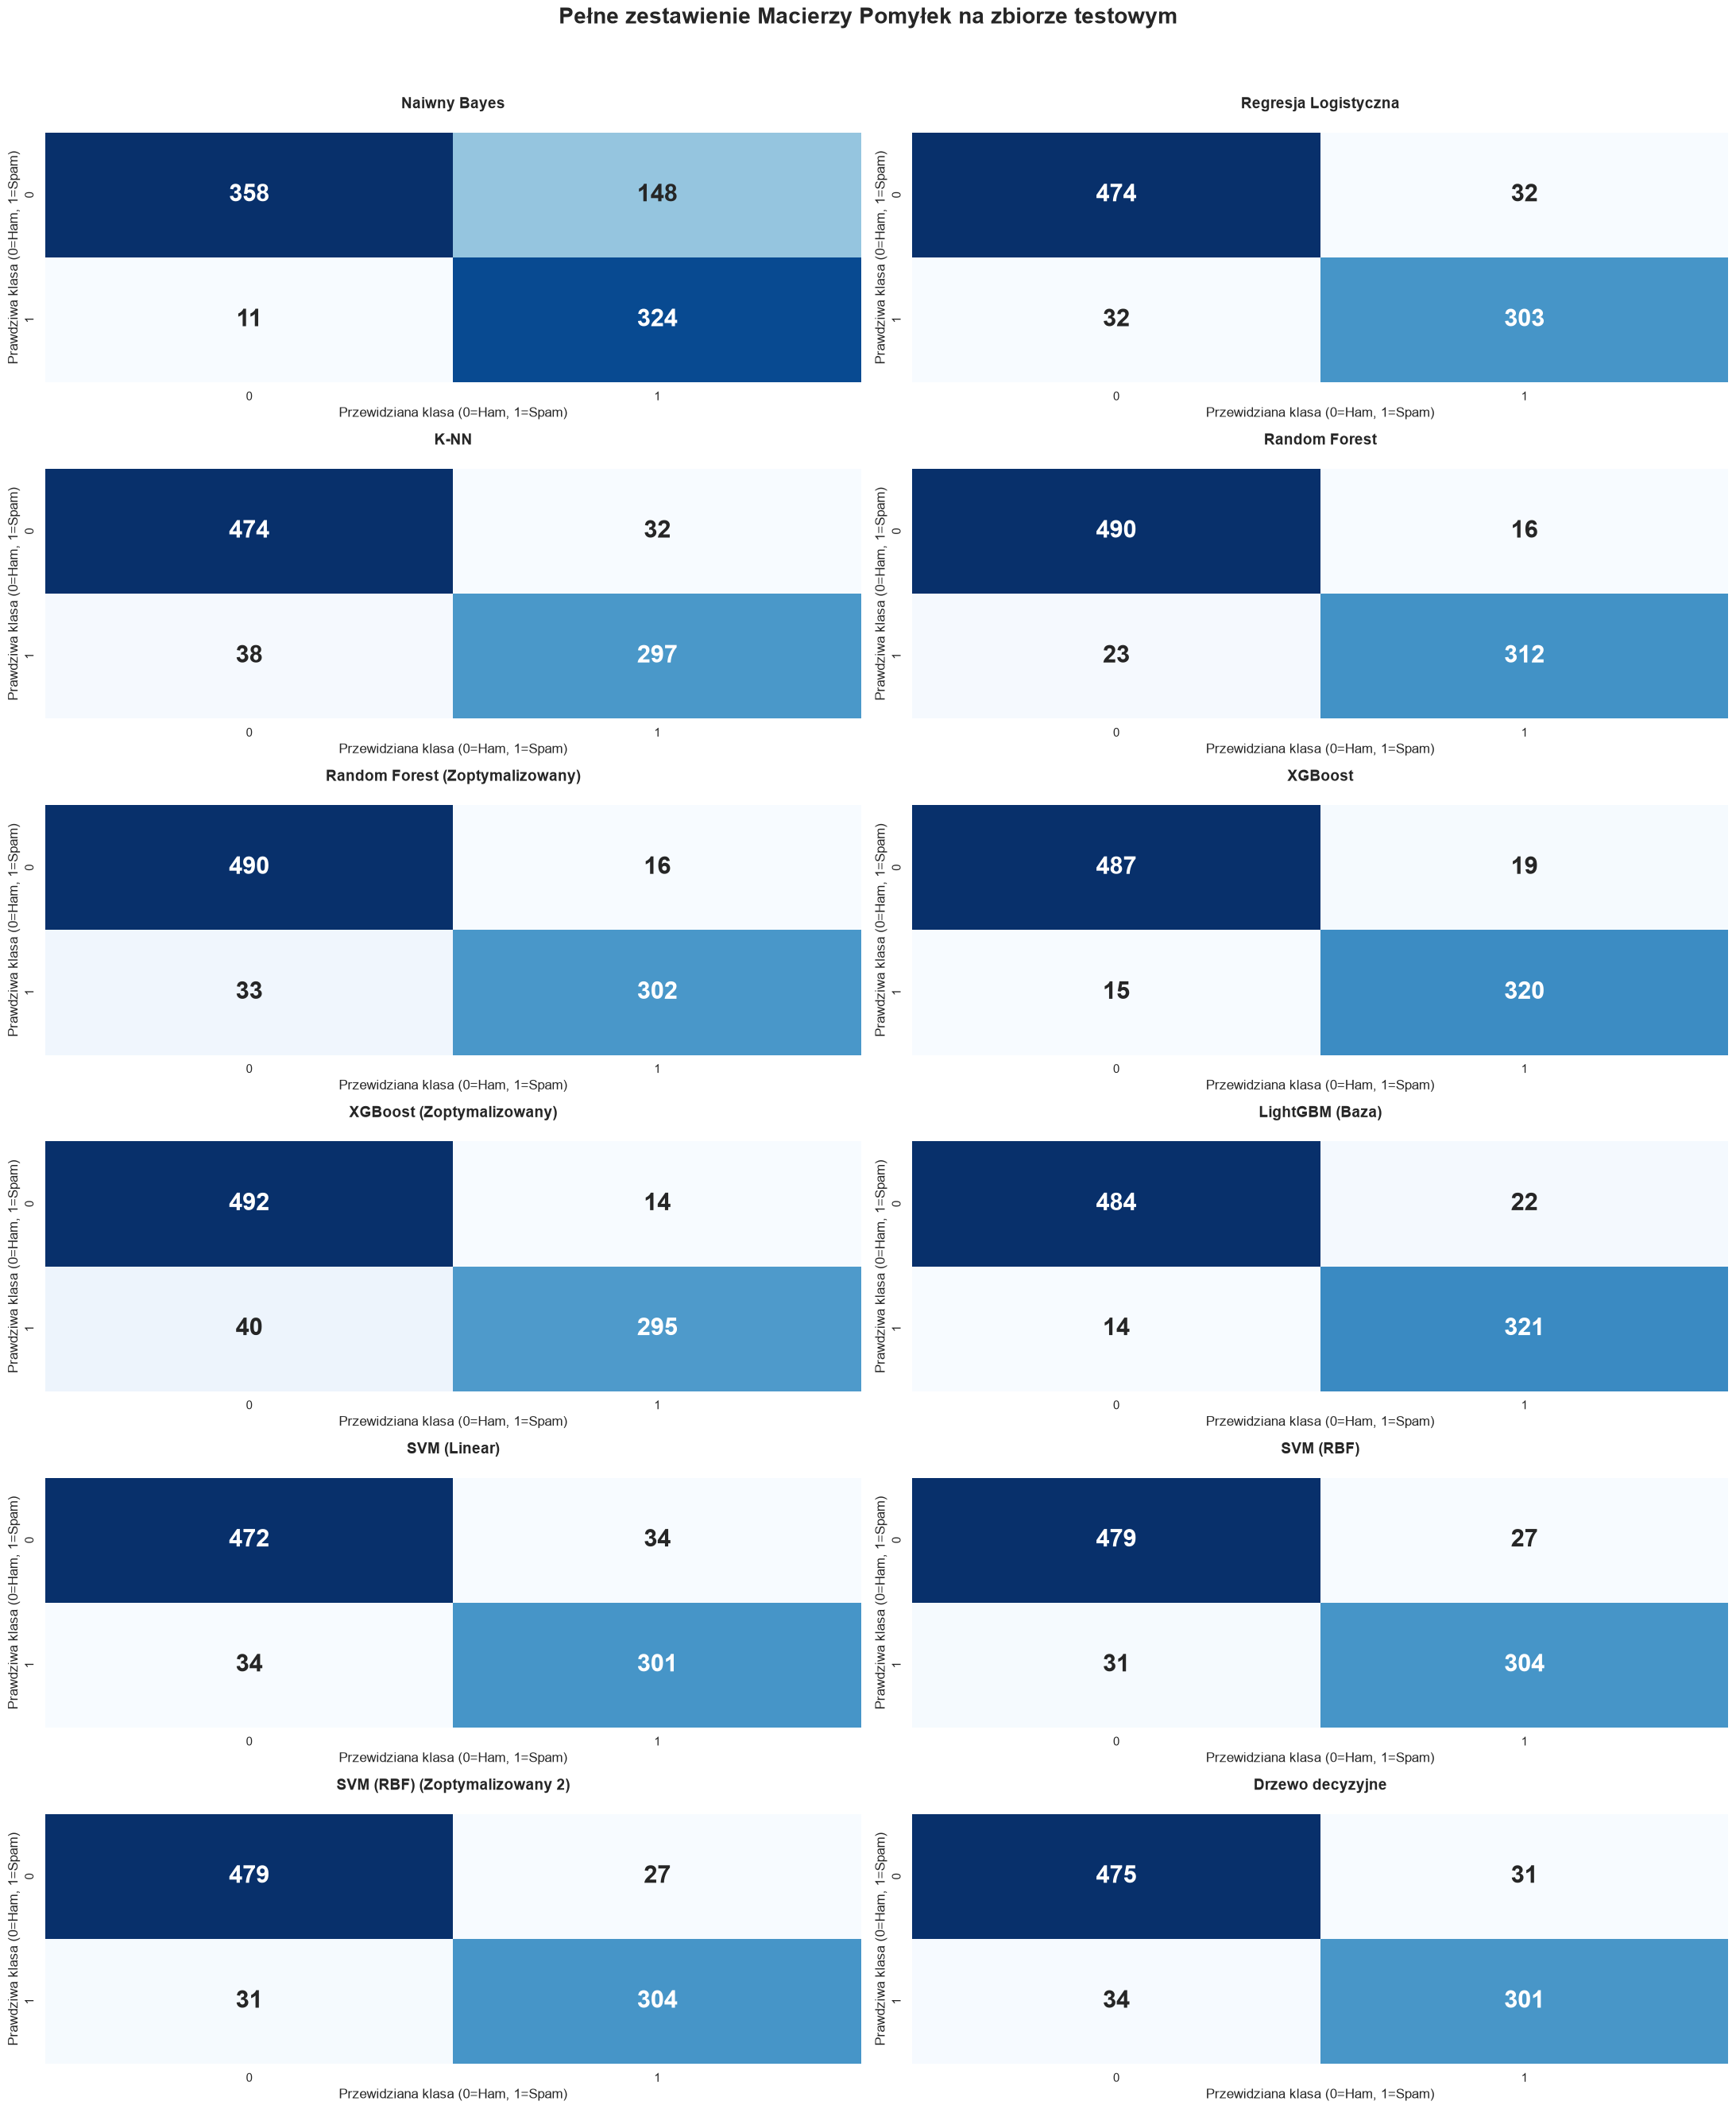


Generowanie krzywych ROC...


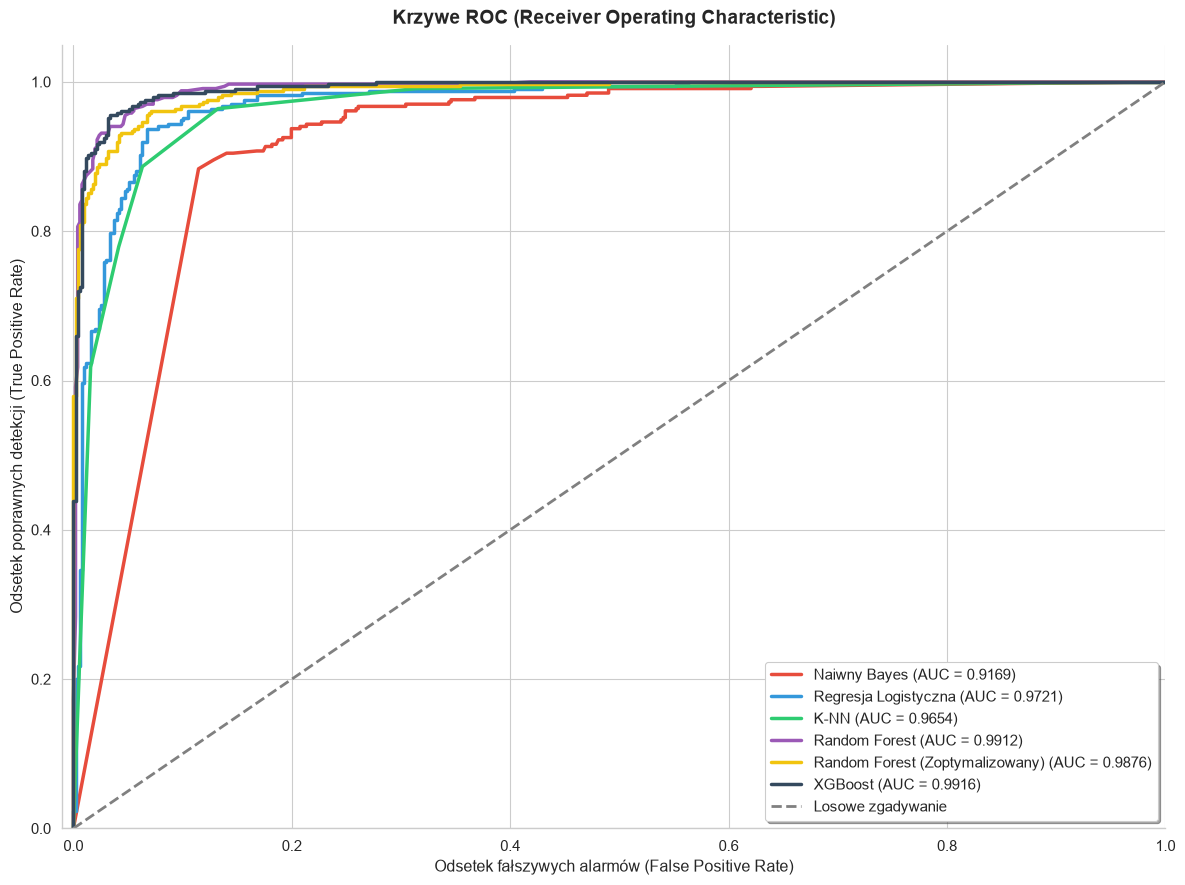


Generowanie wykresu istotności cech...


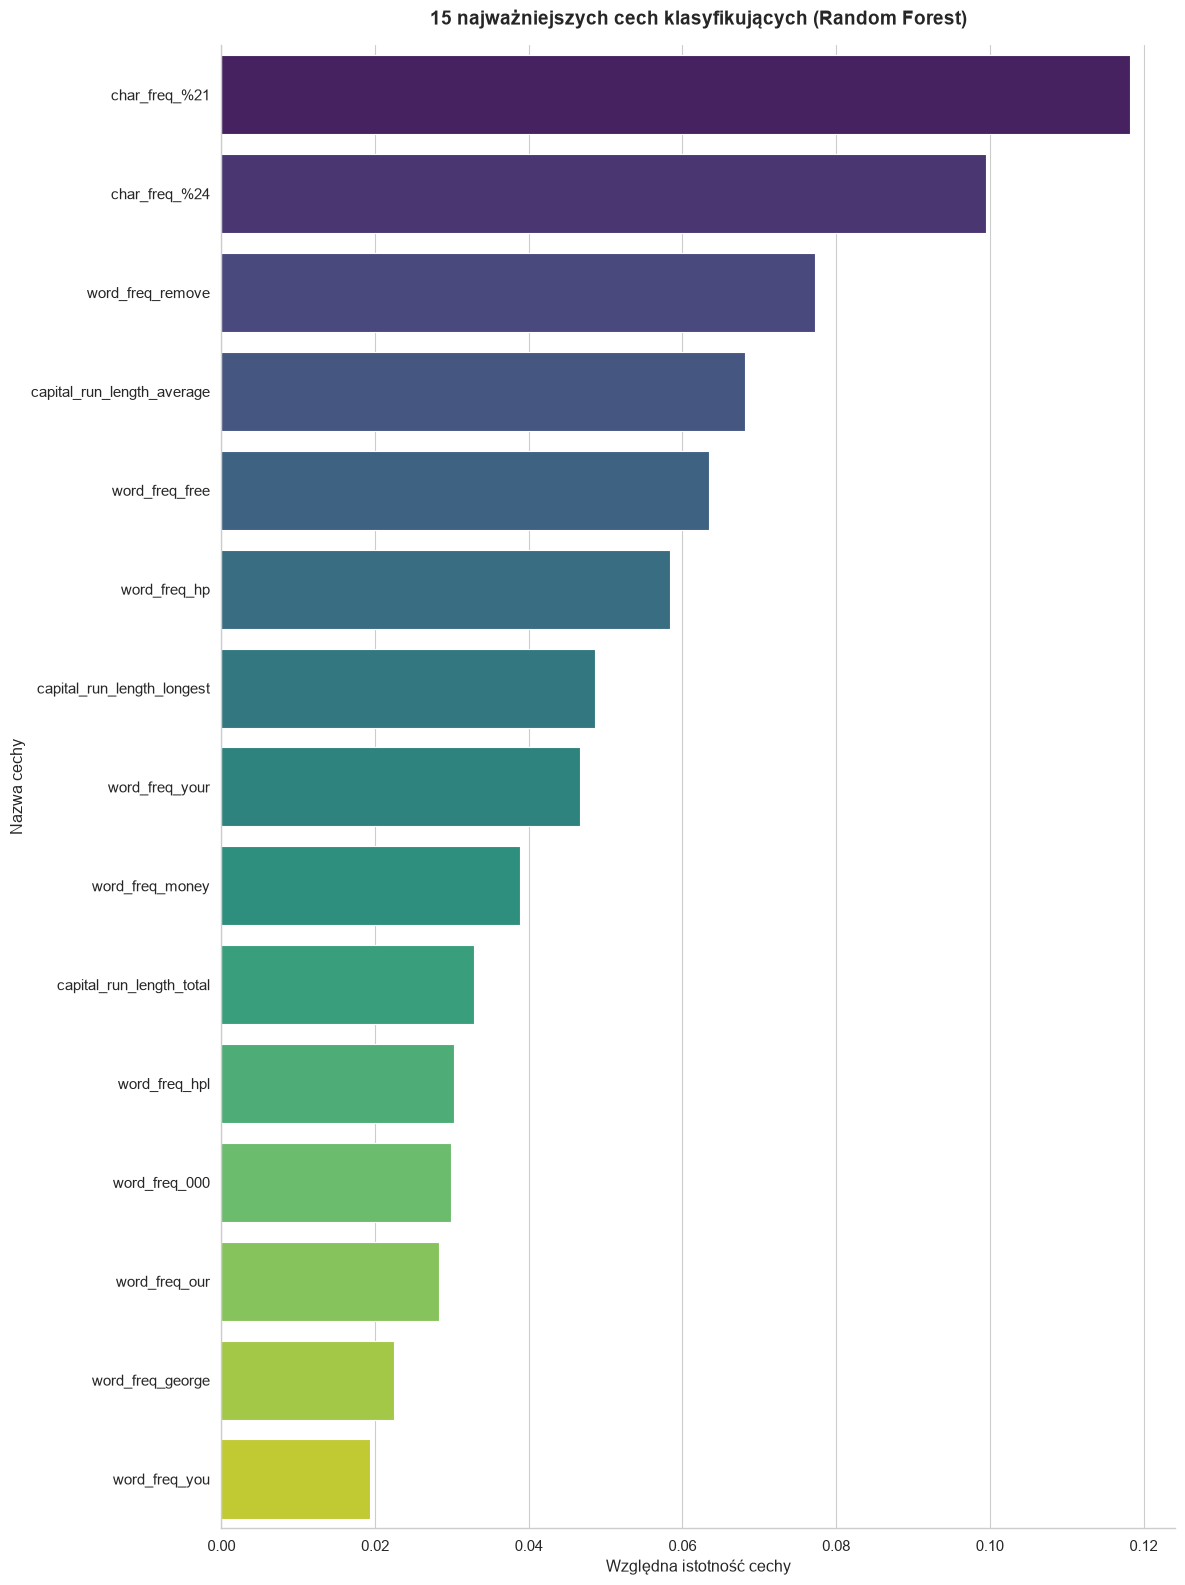

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

# Ustawienia estetyczne wykresów do pracy dyplomowej
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)


# ==========================================
# WYKRES 1: MACIERZE POMYŁEK (Siatka 2x6 dla WSZYSTKICH modeli)
# ==========================================
print("Generowanie macierzy pomyłek dla wszystkich modeli...")

# Pobieramy nazwy wszystkich wczytanych modeli automatycznie
cm_models_to_plot = list(loaded_models.keys())

# Tworzymy dużą siatkę: 2 wiersze na 3 kolumny
fig, axes = plt.subplots(6, 2, figsize=(22, 26))
fig.suptitle('Pełne zestawienie Macierzy Pomyłek na zbiorze testowym', fontsize=20, fontweight='bold', y=1.02)

# Spłaszczamy tablicę osi, aby łatwo iterować w pętli
axes = axes.flatten()

for i, model_name in enumerate(cm_models_to_plot):
    model = loaded_models[model_name]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Rysowanie mapy ciepła dla konkretnej macierzy
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                annot_kws={"size": 22, "weight": "bold"})
    axes[i].set_title(model_name, pad=22, fontweight='bold', fontsize=14)
    axes[i].set_xlabel('Przewidziana klasa (0=Ham, 1=Spam)', fontsize=12)
    axes[i].set_ylabel('Prawdziwa klasa (0=Ham, 1=Spam)', fontsize=12)

plt.tight_layout()
plt.savefig('01_macierze_pomylek_wszystkie.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# WYKRES 2: KRZYWE ROC I POLE AUC
# ==========================================
print("\nGenerowanie krzywych ROC...")
plt.figure(figsize=(12, 9))

# Definicja kolorów dla różnych modeli
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f1c40f', '#34495e']

for (name, model), color in zip(loaded_models.items(), colors):
    # Modele SVM z jądrem RBF domyślnie nie zwracają predict_proba w sklearn, chyba że ustawimy probability=True
    # Aby uniknąć błędu, używamy decision_function dla SVM, a predict_proba dla reszty
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
        
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Losowe zgadywanie')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Odsetek fałszywych alarmów (False Positive Rate)')
plt.ylabel('Odsetek poprawnych detekcji (True Positive Rate)')
plt.title('Krzywe ROC (Receiver Operating Characteristic)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", frameon=True, shadow=True, fontsize=11)
sns.despine()

plt.tight_layout()
plt.savefig('02_krzywe_roc.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# WYKRES 3: ISTOTNOŚĆ CECH (Feature Importance)
# ==========================================
print("\nGenerowanie wykresu istotności cech...")
best_model = loaded_models["Random Forest (Zoptymalizowany)"]

importances = best_model.feature_importances_
feature_names = X_test.columns

df_importances = pd.DataFrame({'Cecha': feature_names, 'Istotność': importances})
df_importances = df_importances.sort_values(by='Istotność', ascending=False).head(15)

plt.figure(figsize=(12, 16))
sns.barplot(x='Istotność', y='Cecha', data=df_importances, palette='viridis')

plt.title('15 najważniejszych cech klasyfikujących (Random Forest)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Względna istotność cechy')
plt.ylabel('Nazwa cechy')
sns.despine()

plt.tight_layout()
plt.savefig('03_istotnosc_cech.png', dpi=300, bbox_inches='tight')
plt.show()

Obliczanie krzywej uczenia (to może zająć kilkanaście sekund, ponieważ model trenuje się wielokrotnie)...


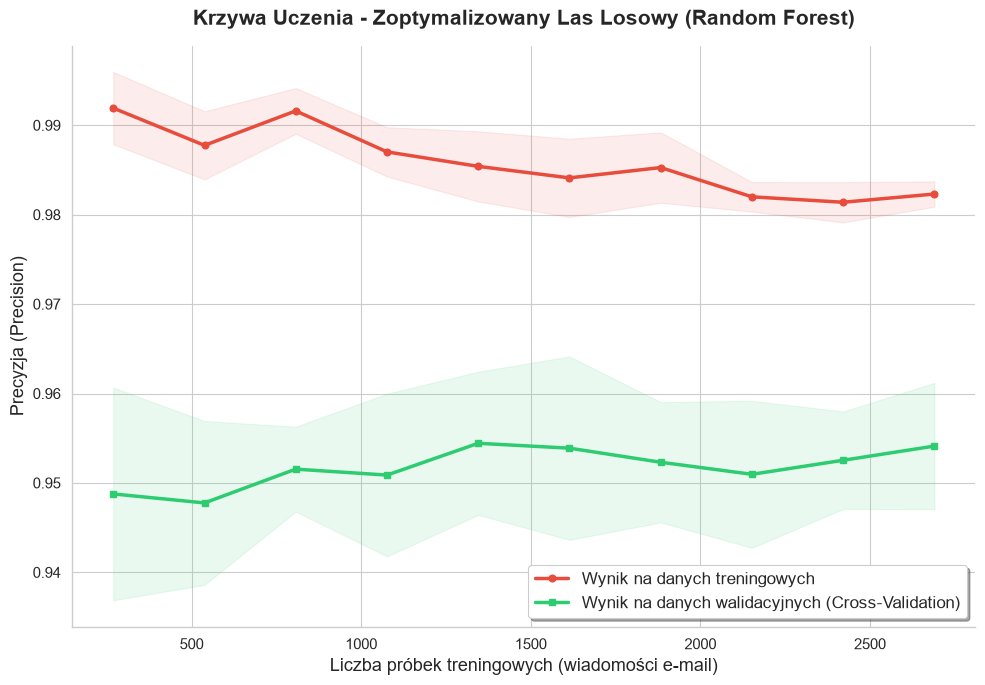

In [43]:


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
import pandas as pd

# Ustawienia estetyczne wykresów
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 1. Wczytanie danych TRENINGOWYCH 
# (Krzywą uczenia liczy się wewnątrz zbioru treningowego przy użyciu walidacji krzyżowej)
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')['target']

# 2. Wybór zwycięskiego modelu z naszego słownika (wcześniej utworzonego)
best_model = loaded_models["Random Forest (Zoptymalizowany)"]

print("Obliczanie krzywej uczenia (to może zająć kilkanaście sekund, ponieważ model trenuje się wielokrotnie)...")

# 3. Obliczenie wartości do krzywej uczenia
# Zgodnie z naszą strategią mierzymy 'precision'
train_sizes, train_scores, val_scores = learning_curve(
    best_model, 
    X_train, 
    y_train, 
    cv=5, 
    scoring='precision',
    n_jobs=-1, # Używa wszystkich dostępnych rdzeni procesora
    train_sizes=np.linspace(0.1, 1.0, 10) # 10 punktów pomiarowych (od 10% do 100% danych)
)

# 4. Obliczenie średnich i odchyleń standardowych
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# 5. Rysowanie wykresu
plt.figure(figsize=(10, 7))
plt.title('Krzywa Uczenia - Zoptymalizowany Las Losowy (Random Forest)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Liczba próbek treningowych (wiadomości e-mail)', fontsize=13)
plt.ylabel('Precyzja (Precision)', fontsize=13)

# Rysowanie obszarów wariancji (odchylenie standardowe)
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="#e74c3c")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.1, color="#2ecc71")

# Rysowanie głównych krzywych
plt.plot(train_sizes, train_scores_mean, 'o-', color="#e74c3c", lw=2.5, label="Wynik na danych treningowych")
plt.plot(train_sizes, val_scores_mean, 's-', color="#2ecc71", lw=2.5, label="Wynik na danych walidacyjnych (Cross-Validation)")

plt.legend(loc="lower right", frameon=True, shadow=True, fontsize=12)
sns.despine()

plt.tight_layout()
plt.savefig('04_krzywa_uczenia.png', dpi=300, bbox_inches='tight')
plt.show()

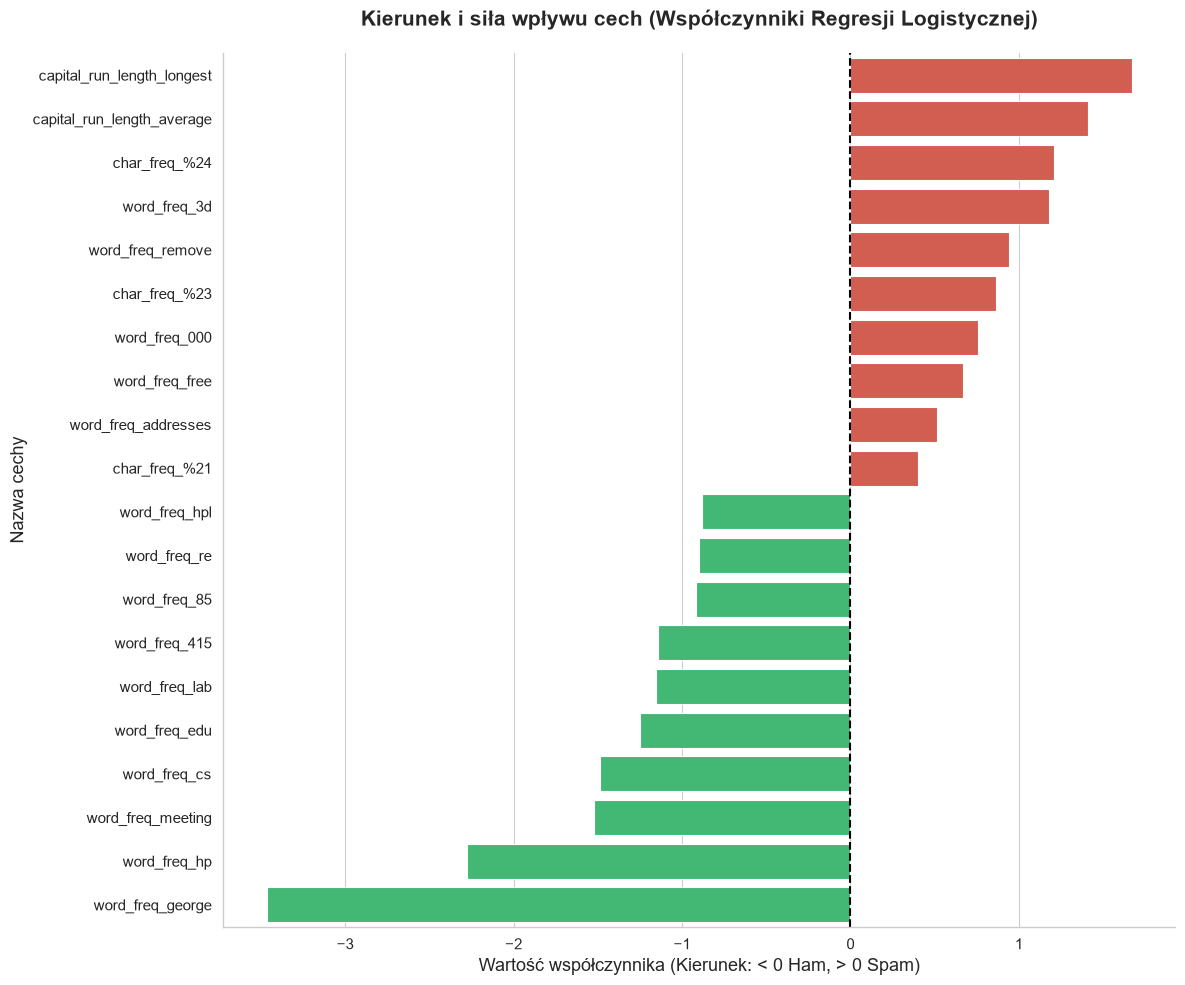

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Ustawienia estetyczne zgodne z resztą pracy
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 1. Wczytanie modelu Regresji Logistycznej i danych testowych (dla pobrania nazw kolumn)
log_reg_model = joblib.load('../models/logistic_regression_cv.pkl')
X_test = pd.read_csv('../data/processed/X_test.csv')

# 2. Pobranie współczynników (wag) z modelu
# W modelu binarnym współczynniki znajdują się w pierwszej tablicy coef_[0]
coefficients = log_reg_model.coef_[0]
feature_names = X_test.columns

# 3. Utworzenie struktury DataFrame i posortowanie wag
df_coef = pd.DataFrame({'Cecha': feature_names, 'Waga': coefficients})
df_coef = df_coef.sort_values(by='Waga', ascending=False)

# 4. Wybór 10 najsilniej wpływających na SPAM (wagi > 0) i 10 na HAM (wagi < 0)
top_spam_features = df_coef.head(10)
top_ham_features = df_coef.tail(10)

# Połączenie ich w jeden zbiór do wyświetlenia na wykresie
df_plot = pd.concat([top_spam_features, top_ham_features])

# 5. Generowanie wykresu
plt.figure(figsize=(12, 10))

# Definicja kolorów: czerwony dla wartości dodatnich (Spam), zielony dla ujemnych (Ham)
colors = ['#e74c3c' if waga > 0 else '#2ecc71' for waga in df_plot['Waga']]

sns.barplot(x='Waga', y='Cecha', data=df_plot, palette=colors)

# Dodanie osi zerowej ułatwiającej czytelność
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

plt.title('Kierunek i siła wpływu cech (Współczynniki Regresji Logistycznej)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Wartość współczynnika (Kierunek: < 0 Ham, > 0 Spam)', fontsize=13)
plt.ylabel('Nazwa cechy', fontsize=13)
sns.despine()

plt.tight_layout()
plt.savefig('05_wspolczynniki_regresji.png', dpi=300, bbox_inches='tight')
plt.show()


Generowanie wykresu porównawczego: Trening vs Test (Precyzja)...


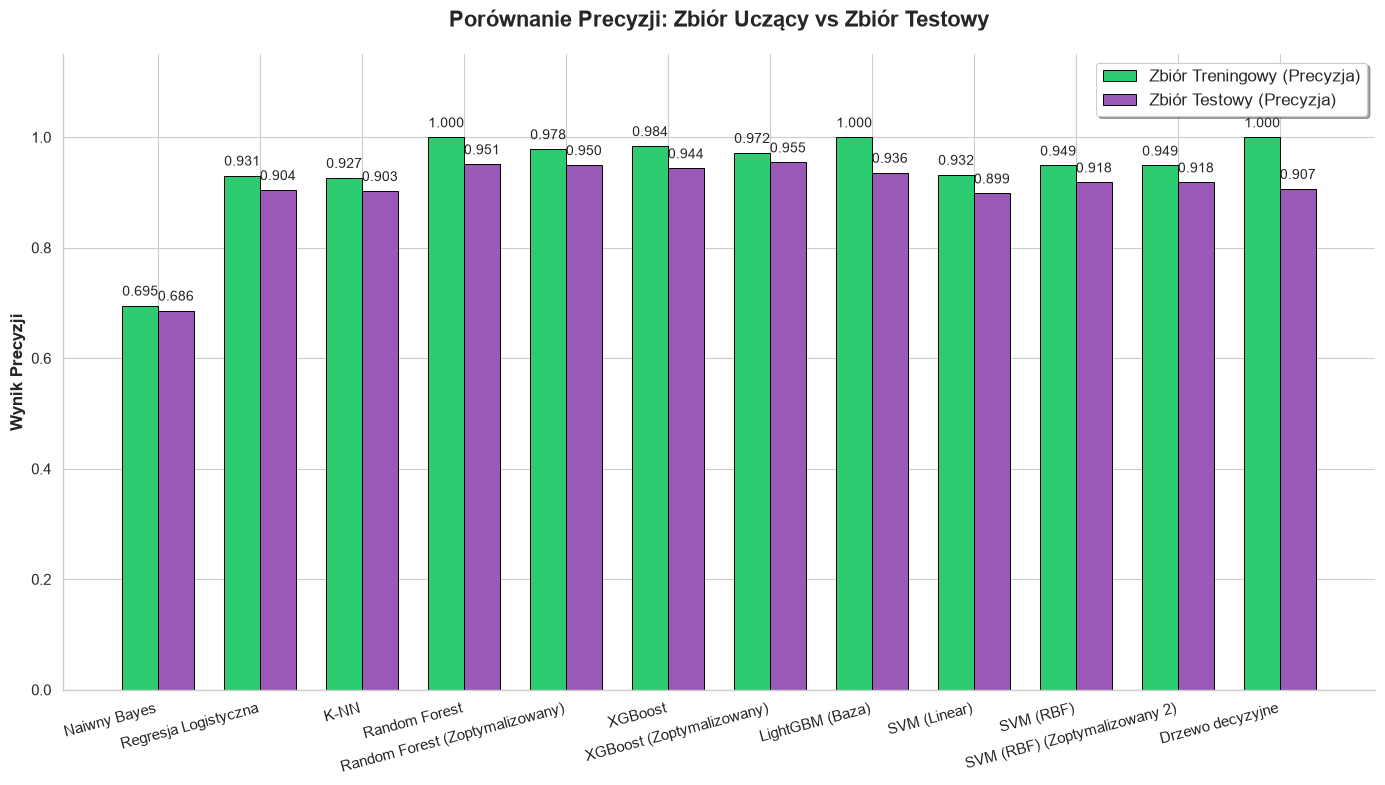

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score
# Zakładam, że pandas i joblib są zaimportowane wcześnie, oraz loaded_models jest podpięty

# ==========================================
# WYKRES 4: PORÓWNANIE TRENING VS TEST (PRECYZJA)
# ==========================================
print("\nGenerowanie wykresu porównawczego: Trening vs Test (Precyzja)...")

# 1. Wczytanie danych treningowych (wymagane do obliczenia wyników na zbiorze uczącym)
try:
    X_train = pd.read_csv('../data/processed/X_train.csv')
    y_train = pd.read_csv('../data/processed/y_train.csv')['target']
except FileNotFoundError:
    print("Błąd: Nie znaleziono plików X_train.csv lub y_train.csv. Upewnij się, że są w '../data/processed/'.")
    raise

# 2. Obliczanie wyników dla Precyzji
model_names_list = []
train_precision_scores = []
test_precision_scores = []

for name, model in loaded_models.items():
    model_names_list.append(name)
    
    # Przewidywania
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Obliczanie precyzji (zero_division=0 chroni przed błędem z dzieleniem przez 0 
    # w przypadku, gdy model nie przewidzi ani jednej klasy 1)
    train_precision_scores.append(precision_score(y_train, y_train_pred, zero_division=0))
    test_precision_scores.append(precision_score(y_test, y_test_pred, zero_division=0))

# 3. Ustawienia wykresu
x_pos = np.arange(len(model_names_list))
width = 0.35  

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(14, 8))

# 4. Rysowanie słupków (nowe kolory dla odróżnienia od poprzednich wykresów)
bars_train = plt.bar(x_pos - width/2, train_precision_scores, width, 
                     label='Zbiór Treningowy (Precyzja)', color='#2ecc71', edgecolor='black', linewidth=0.7)
bars_test = plt.bar(x_pos + width/2, test_precision_scores, width, 
                    label='Zbiór Testowy (Precyzja)', color='#9b59b6', edgecolor='black', linewidth=0.7)

# 5. Funkcja do dodawania etykiet nad słupkami
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.3f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 5),  # Przesunięcie o 5 punktów w górę
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, rotation=0)

add_value_labels(bars_train)
add_value_labels(bars_test)

# 6. Formatowanie estetyczne
plt.ylabel('Wynik Precyzji', fontsize=12, fontweight='bold')
plt.title('Porównanie Precyzji: Zbiór Uczący vs Zbiór Testowy', 
          fontsize=16, fontweight='bold', pad=20)

# Ustawienie nazw modeli na osi X
plt.xticks(x_pos, model_names_list, rotation=15, ha='right', fontsize=11)
plt.ylim(0, 1.15) # Podbicie osi Y, żeby etykiety się zmieściły

plt.legend(loc='upper right', frameon=True, fontsize=12, shadow=True)
sns.despine() # Usunięcie górnej i prawej ramki wykresu

# 7. Zapis i wyświetlenie
plt.tight_layout()
plt.savefig('04_trening_vs_test_precyzja.png', dpi=300, bbox_inches='tight')
plt.show()


Generowanie wykresu porównawczego: Trening vs Test (Swoistość)...


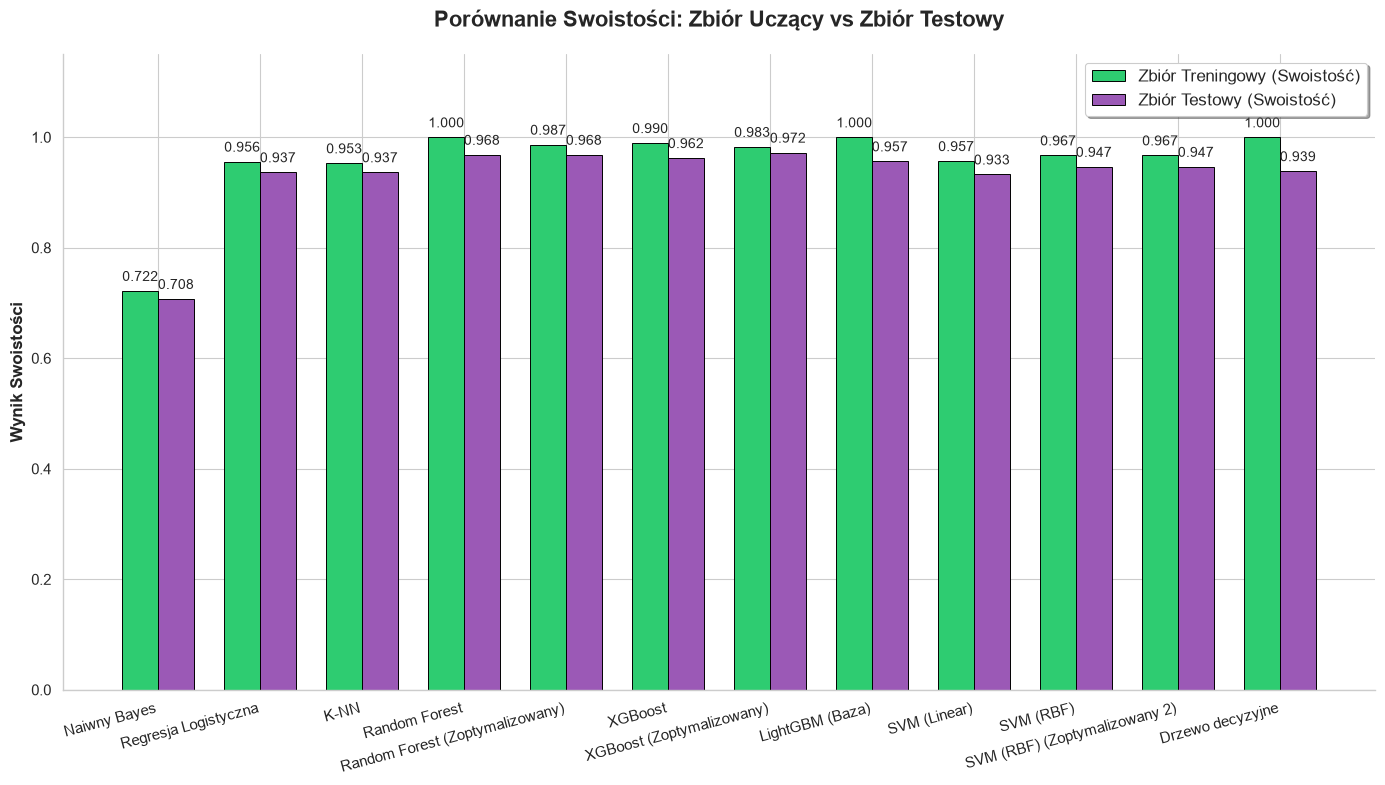

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# WYKRES 4: PORÓWNANIE TRENING VS TEST (SWOISTOŚĆ)
# ==========================================
print("\nGenerowanie wykresu porównawczego: Trening vs Test (Swoistość)...")

# 1. Wczytanie danych treningowych (wymagane do obliczenia wyników na zbiorze uczącym)
try:
    X_train = pd.read_csv('../data/processed/X_train.csv')
    y_train = pd.read_csv('../data/processed/y_train.csv')['target']
except FileNotFoundError:
    print("Błąd: Nie znaleziono plików X_train.csv lub y_train.csv. Upewnij się, że są w '../data/processed/'.")
    raise

# 2. Obliczanie wyników dla Swoistości
model_names_list = []
train_specificity_scores = []
test_specificity_scores = []

for name, model in loaded_models.items():
    model_names_list.append(name)
    
    # Przewidywania
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Obliczanie swoistości (Specificity = TN / (TN + FP)) dla zbioru treningowego
    tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, y_train_pred).ravel()
    train_spec = tn_train / (tn_train + fp_train) if (tn_train + fp_train) > 0 else 0
    train_specificity_scores.append(train_spec)
    
    # Obliczanie swoistości dla zbioru testowego
    tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, y_test_pred).ravel()
    test_spec = tn_test / (tn_test + fp_test) if (tn_test + fp_test) > 0 else 0
    test_specificity_scores.append(test_spec)

# 3. Ustawienia wykresu
x_pos = np.arange(len(model_names_list))
width = 0.35  

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(14, 8))

# 4. Rysowanie słupków (kolory zachowane z poprzedniej wersji)
bars_train = plt.bar(x_pos - width/2, train_specificity_scores, width, 
                     label='Zbiór Treningowy (Swoistość)', color='#2ecc71', edgecolor='black', linewidth=0.7)
bars_test = plt.bar(x_pos + width/2, test_specificity_scores, width, 
                    label='Zbiór Testowy (Swoistość)', color='#9b59b6', edgecolor='black', linewidth=0.7)

# 5. Funkcja do dodawania etykiet nad słupkami
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.3f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 5),  # Przesunięcie o 5 punktów w górę
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, rotation=0)

add_value_labels(bars_train)
add_value_labels(bars_test)

# 6. Formatowanie estetyczne
plt.ylabel('Wynik Swoistości', fontsize=12, fontweight='bold')
plt.title('Porównanie Swoistości: Zbiór Uczący vs Zbiór Testowy', 
          fontsize=16, fontweight='bold', pad=20)

# Ustawienie nazw modeli na osi X
plt.xticks(x_pos, model_names_list, rotation=15, ha='right', fontsize=11)
plt.ylim(0, 1.15) # Podbicie osi Y, żeby etykiety się zmieściły

plt.legend(loc='upper right', frameon=True, fontsize=12, shadow=True)
sns.despine() # Usunięcie górnej i prawej ramki wykresu

# 7. Zapis i wyświetlenie
plt.tight_layout()
plt.savefig('04_trening_vs_test_swoistosc.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
print(f"Liczba modeli w pamięci: {len(loaded_models)}")
print("Lista dostępnych modeli:")
for name in loaded_models.keys():
    print(f"- {name}")

Liczba modeli w pamięci: 12
Lista dostępnych modeli:
- Naiwny Bayes
- Regresja Logistyczna
- K-NN
- Random Forest
- Random Forest (Zoptymalizowany)
- XGBoost
- XGBoost (Zoptymalizowany)
- LightGBM (Baza)
- SVM (Linear)
- SVM (RBF)
- SVM (RBF) (Zoptymalizowany 2)
- Drzewo decyzyjne



Generowanie wykresu porównawczego: Trening vs Test...


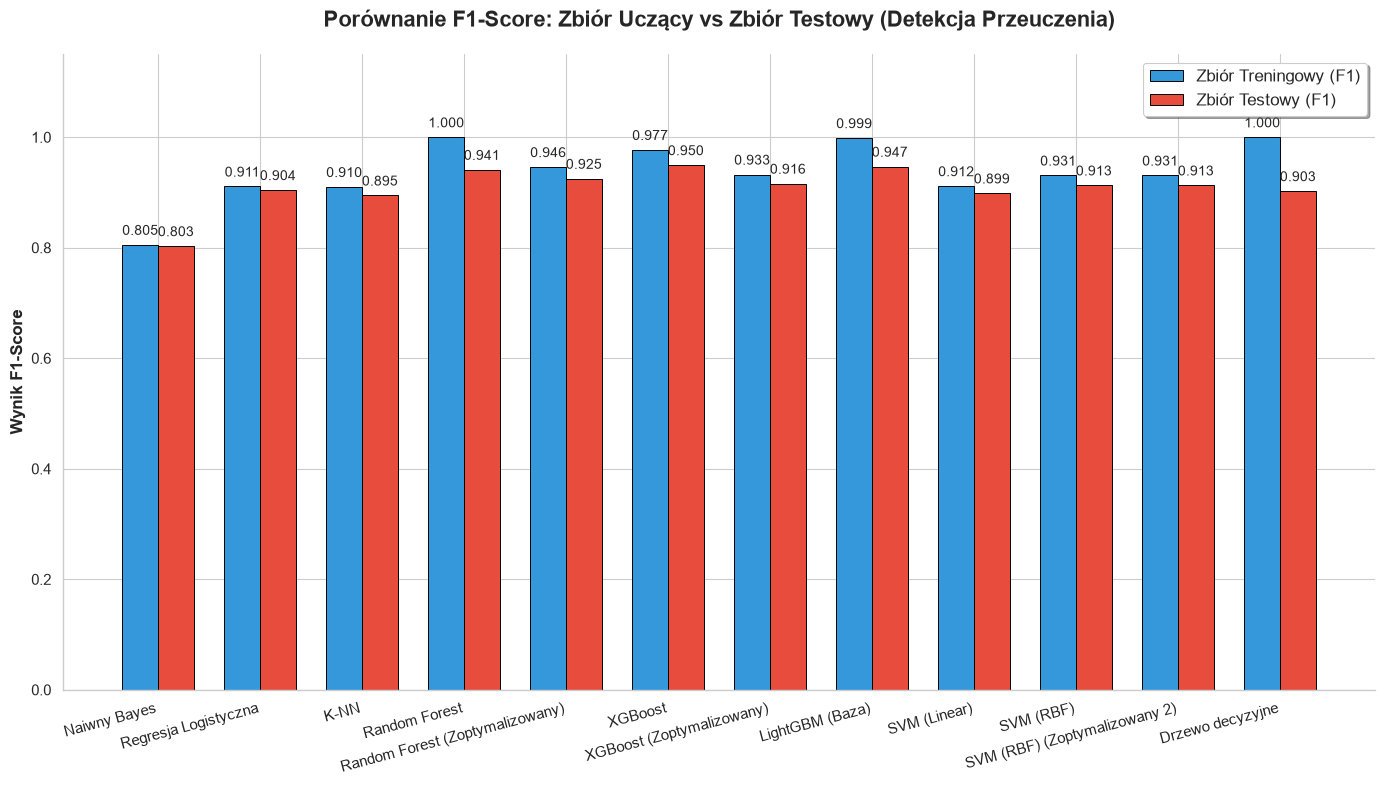

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
# Zakładam, że pandas i joblib są zaimportowane wcześnie, oraz loaded_models jest podpięty

# ==========================================
# WYKRES 4: PORÓWNANIE TRENING VS TEST (F1-SCORE)
# ==========================================
print("\nGenerowanie wykresu porównawczego: Trening vs Test...")

# 1. Wczytanie danych treningowych (wymagane do obliczenia wyników na zbiorze uczącym)
try:
    X_train = pd.read_csv('../data/processed/X_train.csv')
    y_train = pd.read_csv('../data/processed/y_train.csv')['target']
except FileNotFoundError:
    print("Błąd: Nie znaleziono plików X_train.csv lub y_train.csv. Upewnij się, że są w '../data/processed/'.")
    # Kod przerwie wykonywanie tej komórki jeśli nie znajdzie danych
    raise

# 2. Obliczanie wyników
model_names_list = []
train_f1_scores = []
test_f1_scores = []

for name, model in loaded_models.items():
    model_names_list.append(name)
    
    # Przewidywania
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metryki - używam F1-Score jako głównej metryki równowagi (możesz zmienić na accuracy_score)
    train_f1_scores.append(f1_score(y_train, y_train_pred))
    test_f1_scores.append(f1_score(y_test, y_test_pred))

# 3. Ustawienia wykresu
x_pos = np.arange(len(model_names_list))
width = 0.35  

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(14, 8))

# 4. Rysowanie słupków
bars_train = plt.bar(x_pos - width/2, train_f1_scores, width, 
                     label='Zbiór Treningowy (F1)', color='#3498db', edgecolor='black', linewidth=0.7)
bars_test = plt.bar(x_pos + width/2, test_f1_scores, width, 
                    label='Zbiór Testowy (F1)', color='#e74c3c', edgecolor='black', linewidth=0.7)

# 5. Funkcja do dodawania etykiet nad słupkami
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.3f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 5),  # Przesunięcie o 5 punktów w górę
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, rotation=0)

add_value_labels(bars_train)
add_value_labels(bars_test)

# 6. Formatowanie estetyczne
plt.ylabel('Wynik F1-Score', fontsize=12, fontweight='bold')
plt.title('Porównanie F1-Score: Zbiór Uczący vs Zbiór Testowy (Detekcja Przeuczenia)', 
          fontsize=16, fontweight='bold', pad=20)

# Ustawienie nazw modeli na osi X, lekkie pochylenie ułatwia czytanie długich nazw
plt.xticks(x_pos, model_names_list, rotation=15, ha='right', fontsize=11)
plt.ylim(0, 1.15) # Podbicie osi Y, żeby etykiety się zmieściły

plt.legend(loc='upper right', frameon=True, fontsize=12, shadow=True)
sns.despine() # Usunięcie górnej i prawej ramki wykresu

# 7. Zapis i wyświetlenie
plt.tight_layout()
plt.savefig('04_trening_vs_test.png', dpi=300, bbox_inches='tight')
plt.show()

Obliczanie metryk i generowanie panelu wykresów (2x2)...


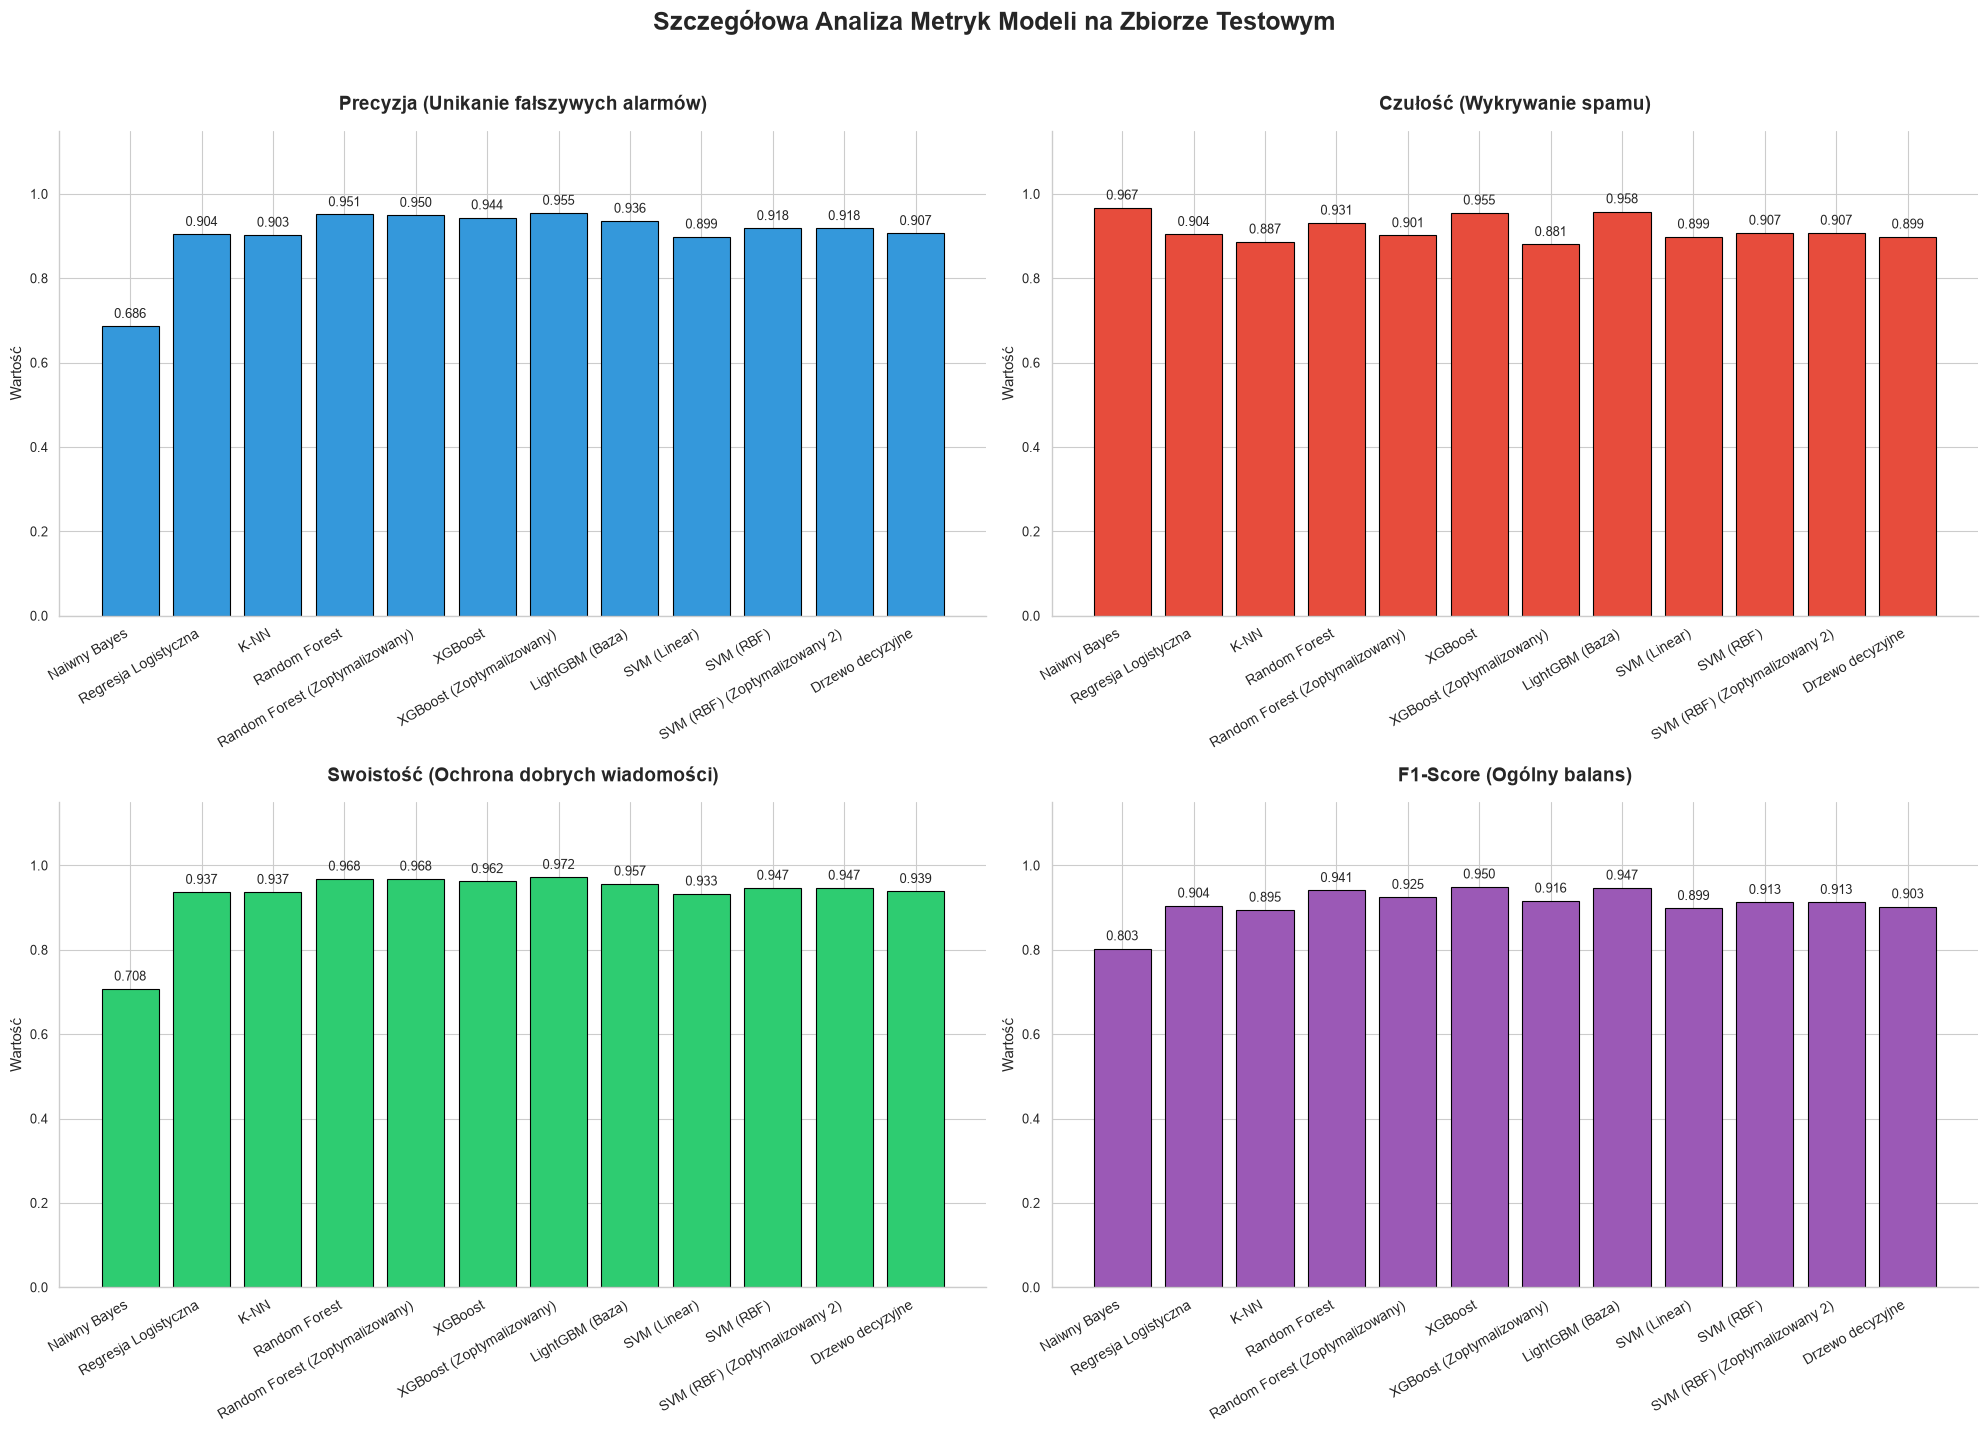

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

print("Obliczanie metryk i generowanie panelu wykresów (2x2)...")

# 1. Przygotowanie danych (zbieramy metryki z modeli)
metrics_data = {
    "Model": [], "Precision": [], "Recall": [], "Specificity": [], "F1-Score": []
}

for name, model in loaded_models.items():
    metrics_data["Model"].append(name)
    y_test_pred = model.predict(X_test)
    
    prec = precision_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
    spec = tn / (tn + fp)
    
    metrics_data["Precision"].append(prec)
    metrics_data["Recall"].append(rec)
    metrics_data["Specificity"].append(spec)
    metrics_data["F1-Score"].append(f1)

df_metrics = pd.DataFrame(metrics_data)
model_names = df_metrics["Model"].tolist()

# 2. Ustawienia globalne wykresu
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
fig, axes = plt.subplots(2, 2, figsize=(20, 14)) # Siatka 2 wiersze na 2 kolumny
axes = axes.flatten() # Spłaszczamy tablicę osi, żeby łatwiej po niej iterować

# Definiujemy metryki i kolory dla każdego z 4 wykresów
metrics = ["Precision", "Recall", "Specificity", "F1-Score"]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
titles = [
    'Precyzja (Unikanie fałszywych alarmów)',
    'Czułość (Wykrywanie spamu)',
    'Swoistość (Ochrona dobrych wiadomości)',
    'F1-Score (Ogólny balans)'
]

# 3. Rysowanie poszczególnych wykresów w pętli
for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(model_names, df_metrics[metric], color=colors[i], edgecolor='black', linewidth=0.8)
    
    ax.set_title(titles[i], fontsize=14, fontweight='bold', pad=15)
    ax.set_ylim(0, 1.15) # Miejsce na etykiety nad słupkami
    ax.set_ylabel('Wartość', fontsize=11)
    
    # Obrócenie nazw modeli na osi X
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=10)
    
    # Dodanie dokładnych wartości liczbowych nad każdym słupkiem
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Szczegółowa Analiza Metryk Modeli na Zbiorze Testowym', fontsize=18, fontweight='bold', y=1.02)
sns.despine()

# 4. Zapis i wyświetlenie
plt.tight_layout()
plt.savefig('05_metryki_panel_2x2.png', dpi=300, bbox_inches='tight')
plt.show()

Generowanie wykresów ważności cech (Feature Importance)...
Znaleziono 6 modeli drzewiastych. Rysuję dla: ['Random Forest', 'Random Forest (Zoptymalizowany)', 'XGBoost', 'XGBoost (Zoptymalizowany)']


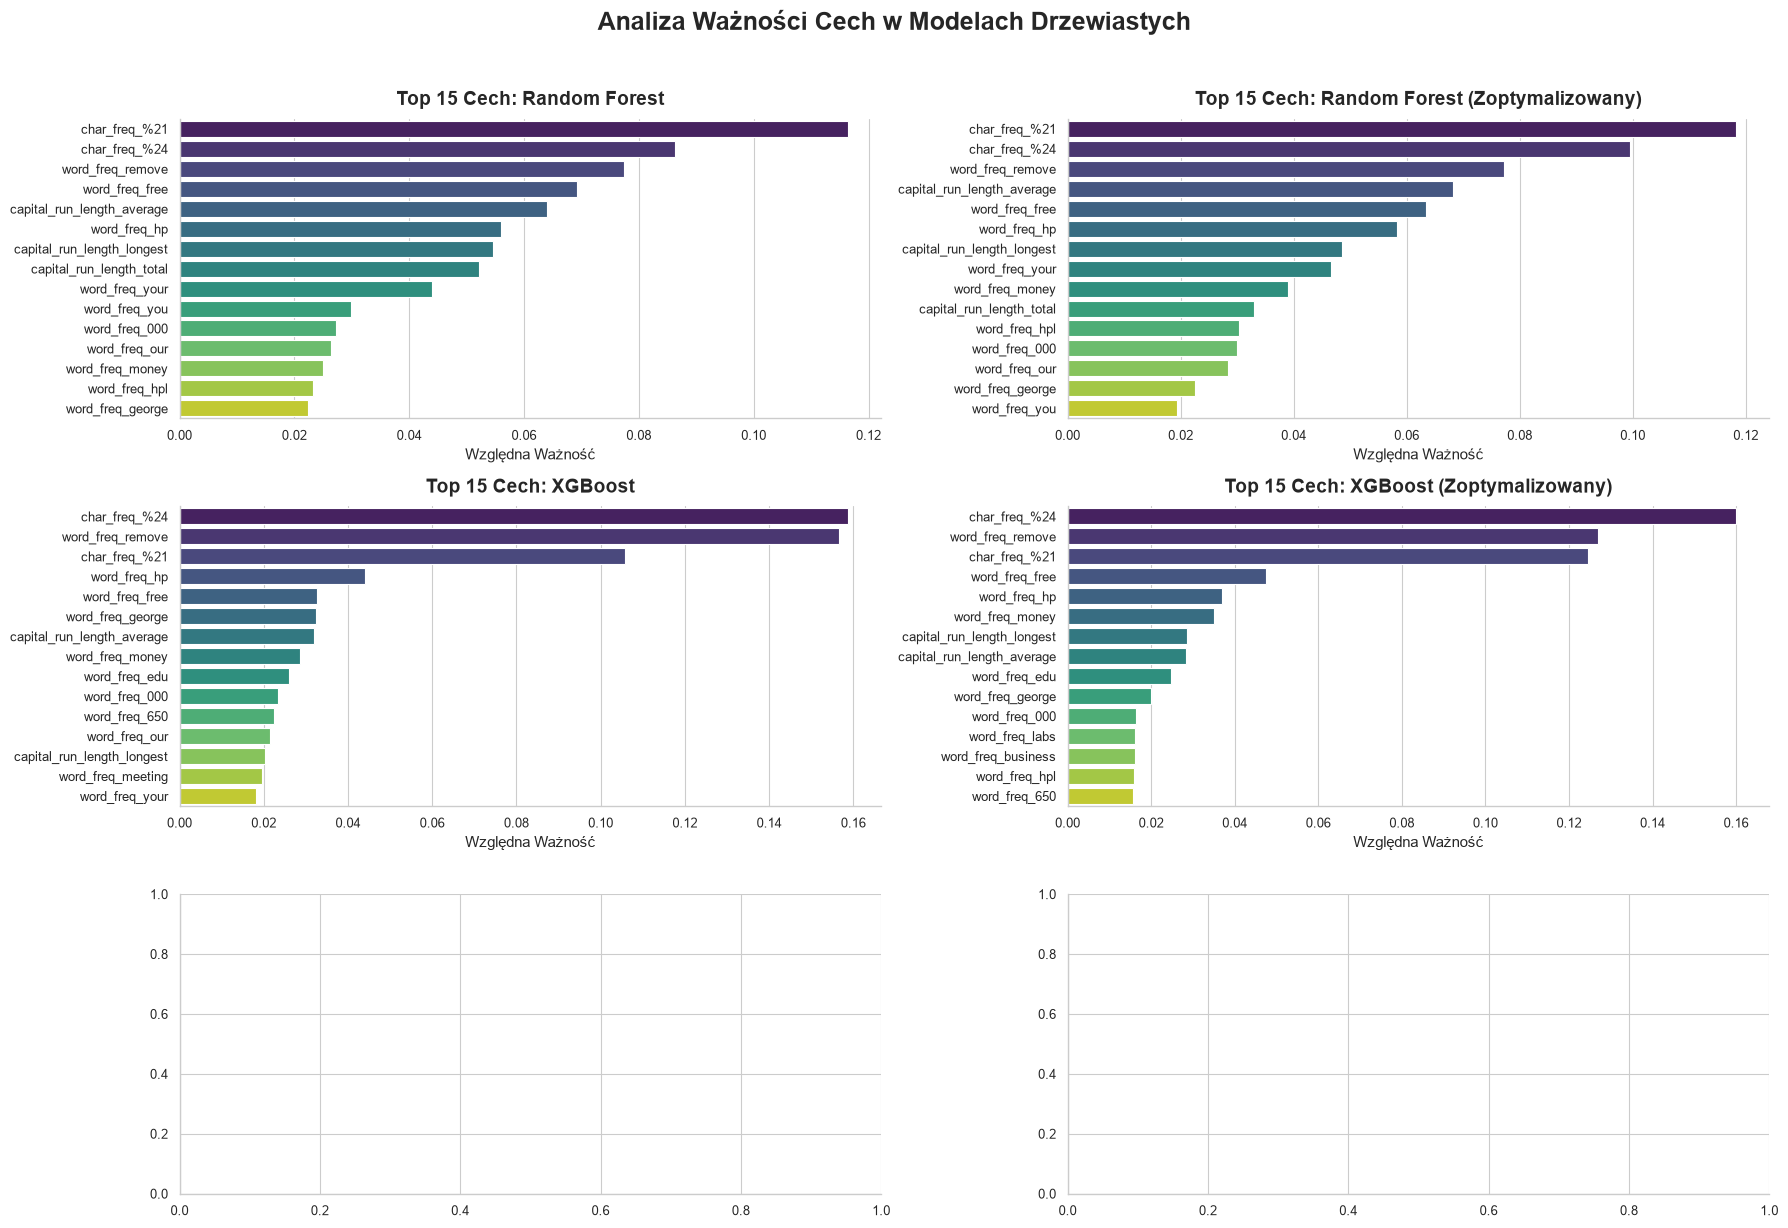

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Generowanie wykresów ważności cech (Feature Importance)...")

# 1. Wczytanie nagłówków kolumn ze zbioru treningowego
try:
    X_train_cols = pd.read_csv('../data/processed/X_train.csv', nrows=0).columns
except FileNotFoundError:
    print("Nie znaleziono pliku X_train.csv. Upewnij się co do ścieżki.")
    raise

# 2. Wybranie tylko tych modeli, które wspierają atrybut feature_importances_
tree_models = {name: model for name, model in loaded_models.items() 
               if hasattr(model, 'feature_importances_')}

# Wybieramy maksymalnie 4 modele do panelu 2x2
models_to_plot = list(tree_models.keys())[:6]
print(f"Znaleziono {len(tree_models)} modeli drzewiastych. Rysuję dla: {models_to_plot}")

# 3. Konfiguracja wykresu
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()

# 4. Rysowanie wykresów w pętli
for i, name in enumerate(models_to_plot):
    model = tree_models[name]
    importances = model.feature_importances_
    
    # Sortowanie cech malejąco i wybór 15 najważniejszych
    indices = np.argsort(importances)[::-1][:15]
    top_features = [X_train_cols[j] for j in indices]
    top_importances = importances[indices]
    
    # Rysowanie poziomego wykresu słupkowego
    sns.barplot(x=top_importances, y=top_features, ax=axes[i], palette='viridis')
    
    axes[i].set_title(f'Top 15 Cech: {name}', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('Względna Ważność', fontsize=11)
    axes[i].set_ylabel('')
    
plt.suptitle('Analiza Ważności Cech w Modelach Drzewiastych', fontsize=18, fontweight='bold', y=1.02)
sns.despine()

# 5. Zapis i wyświetlenie
plt.tight_layout()
plt.savefig('06_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Wczytywanie Drzewa Decyzyjnego...

--- ANATOMIA MODELU ---
Maksymalna głębokość (poziomy decyzyjne): 28
Liczba ostatecznych reguł (liści): 230

Generowanie schematu blokowego...


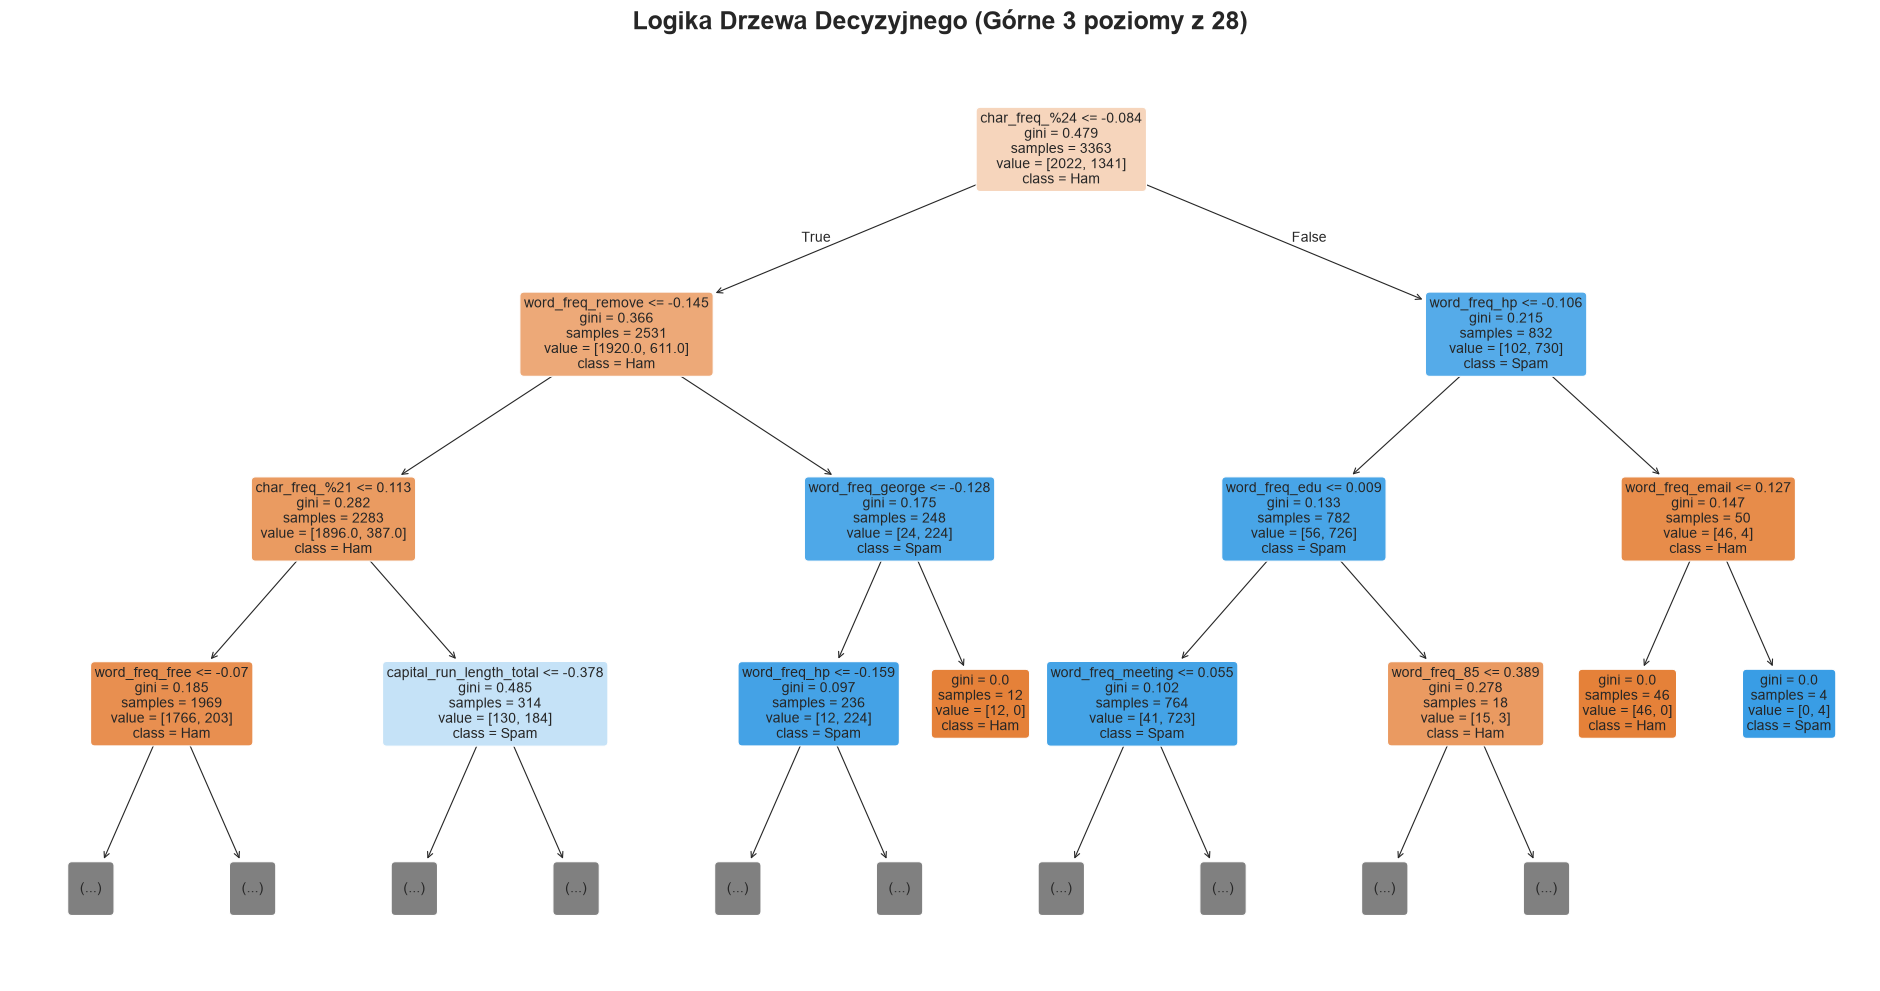


--- GŁÓWNA REGUŁA (KORZEŃ) ---
|--- char_freq_%24 <= -0.08
|   |--- word_freq_remove <= -0.15
|   |   |--- truncated branch of depth 27
|   |--- word_freq_remove >  -0.15
|   |   |--- truncated branch of depth 11
|--- char_freq_%24 >  -0.08
|   |--- word_freq_hp <= -0.11
|   |   |--- truncated branch of depth 19
|   |--- word_freq_hp >  -0.11
|   |   |--- truncated branch of depth 2



In [52]:
from sklearn.tree import plot_tree, export_text
print("Wczytywanie Drzewa Decyzyjnego...\n")
dt_path = model_files["Drzewo decyzyjne"]
dt_model = joblib.load(dt_path)

X_train = pd.read_csv('../data/processed/X_train.csv')

# 3. Analiza fizycznej struktury
depth = dt_model.get_depth()
leaves = dt_model.get_n_leaves()

print("--- ANATOMIA MODELU ---")
print(f"Maksymalna głębokość (poziomy decyzyjne): {depth}")
print(f"Liczba ostatecznych reguł (liści): {leaves}\n")

# 4. Generowanie wykresu drzewa (Top 3 poziomy)
print("Generowanie schematu blokowego...")
plt.figure(figsize=(24, 12))

# Rysujemy górną część drzewa
plot_tree(
    dt_model, 
    max_depth=3,                    # Pokazujemy tylko korzeń i 3 poziomy w dół
    feature_names=X_train.columns,  # Używamy prawdziwych nazw z pliku
    class_names=['Ham', 'Spam'],    # Zamiast 0 i 1
    filled=True,                    # Koloruje węzły (niebieski vs pomarańczowy)
    rounded=True, 
    fontsize=10
)

plt.title(f'Logika Drzewa Decyzyjnego (Górne 3 poziomy z {depth})', fontsize=18, fontweight='bold', pad=20)
plt.savefig('07_struktura_drzewa.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Wyświetlenie korzenia w formie tekstowej
print("\n--- GŁÓWNA REGUŁA (KORZEŃ) ---")
tree_rules = export_text(dt_model, feature_names=list(X_train.columns), max_depth=1)
print(tree_rules)

In [53]:
import joblib
import numpy as np
import pandas as pd

# 1. Ścieżki do modeli i danych
rf_base_path = "../models/random_forest_cv.pkl"
rf_tuned_path = "../models/random_forest_tuned_specificity.pkl"
X_test_path = "../data/processed/X_test.csv"

print("Wczytywanie modeli Random Forest i danych testowych...\n")
rf_base = joblib.load(rf_base_path)
rf_tuned = joblib.load(rf_tuned_path)
X_test = pd.read_csv(X_test_path)

# 2. Funkcja do ekstrakcji hiperparametrów i parametrów fizycznych
def analyze_forest(model, model_name, X_test):
    # --- WYCIĄGANIE HIPERPARAMETRÓW ---
    params = model.get_params()
    
    # --- WYCIĄGANIE WŁAŚCIWOŚCI FIZYCZNYCH ---
    trees = model.estimators_
    n_trees = len(trees)
    
    depths = [tree.get_depth() for tree in trees]
    leaves = [tree.get_n_leaves() for tree in trees]
    
    avg_depth = np.mean(depths)
    max_depth_val = np.max(depths)
    total_leaves = np.sum(leaves)
    
    # --- ANALIZA GŁOSOWANIA ---
    probs = model.predict_proba(X_test)
    confidences = np.max(probs, axis=1)
    avg_confidence = np.mean(confidences) * 100
    uncertain_votes = np.sum((confidences >= 0.50) & (confidences <= 0.55))
    
    # --- WYŚWIETLANIE WYNIKÓW ---
    print(f"================ {model_name.upper()} ================")
    print("--- 1. USTAWIENIA (HIPERPARAMETRY) ---")
    print(f"Liczba drzew (n_estimators):       {params.get('n_estimators')}")
    print(f"Max głębokość (max_depth):         {params.get('max_depth')}")
    print(f"Min próbek do podziału (min_samples_split): {params.get('min_samples_split')}")
    print(f"Min próbek w liściu (min_samples_leaf):   {params.get('min_samples_leaf')}")
    print(f"Kryterium podziału (criterion):    {params.get('criterion')}")
    
    print("\n--- 2. FIZYCZNA STRUKTURA LASU ---")
    print(f"Faktyczna liczba drzew:            {n_trees}")
    print(f"Średnia głębokość drzewa:          {avg_depth:.1f} (Max osiągnięta: {max_depth_val})")
    print(f"Łączna liczba liści (reguł):       {total_leaves}")
    
    print("\n--- 3. GŁOSOWANIE (NA ZBIORZE TESTOWYM) ---")
    print(f"Średnia pewność decyzji:           {avg_confidence:.1f}%")
    print(f"Liczba wiadomości 'niepewnych':    {uncertain_votes} na {len(X_test)} wiadomości")
    print("==============================================================\n")

# 3. Uruchomienie analizy
analyze_forest(rf_base, "Random Forest (Baza)", X_test)
analyze_forest(rf_tuned, "Random Forest (Zoptymalizowany)", X_test)

Wczytywanie modeli Random Forest i danych testowych...

================ RANDOM FOREST (BAZA) ================
--- 1. USTAWIENIA (HIPERPARAMETRY) ---
Liczba drzew (n_estimators):       100
Max głębokość (max_depth):         None
Min próbek do podziału (min_samples_split): 2
Min próbek w liściu (min_samples_leaf):   1
Kryterium podziału (criterion):    gini

--- 2. FIZYCZNA STRUKTURA LASU ---
Faktyczna liczba drzew:            100
Średnia głębokość drzewa:          31.6 (Max osiągnięta: 46)
Łączna liczba liści (reguł):       28170

--- 3. GŁOSOWANIE (NA ZBIORZE TESTOWYM) ---
Średnia pewność decyzji:           89.7%
Liczba wiadomości 'niepewnych':    21 na 841 wiadomości

================ RANDOM FOREST (ZOPTYMALIZOWANY) ================
--- 1. USTAWIENIA (HIPERPARAMETRY) ---
Liczba drzew (n_estimators):       300
Max głębokość (max_depth):         10
Min próbek do podziału (min_samples_split): 5
Min próbek w liściu (min_samples_leaf):   1
Kryterium podziału (criterion):    gini

--- 2. F

Generowanie histogramów pewności głosowania...


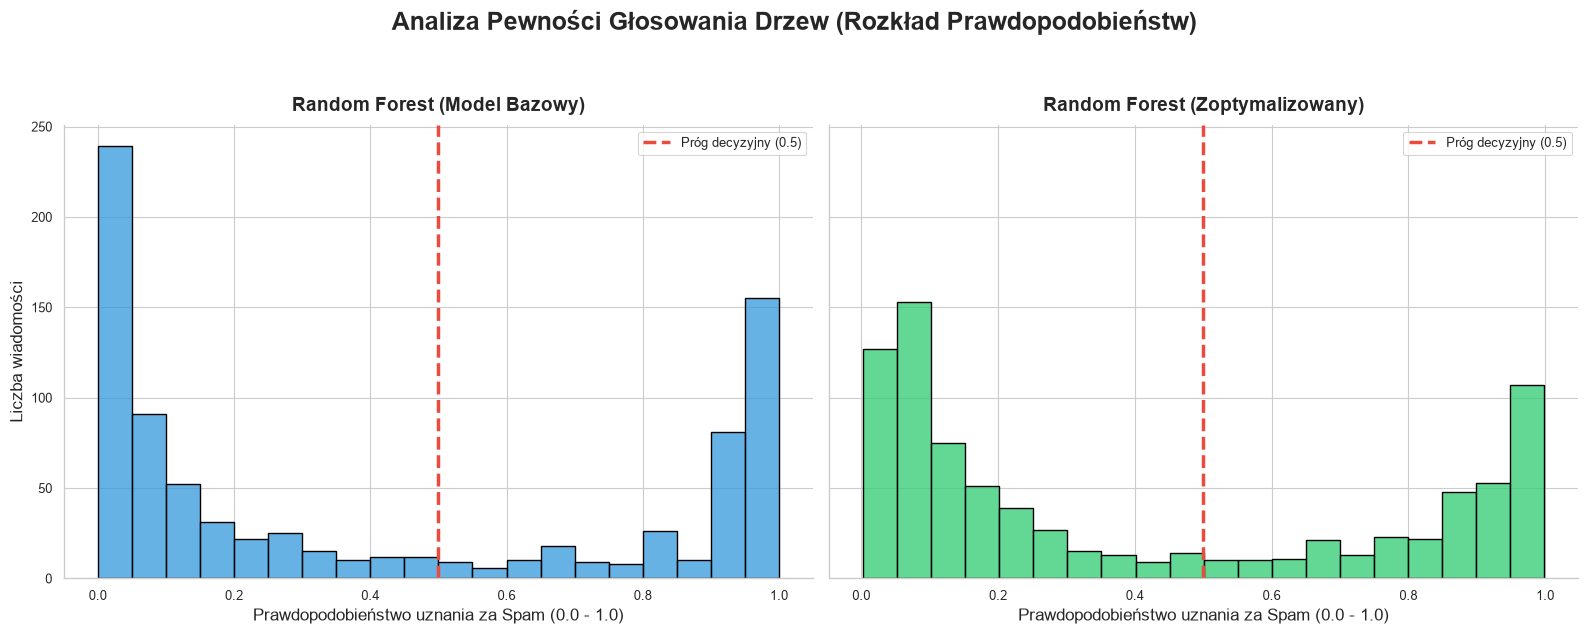

In [ ]:
# Wizualizacja dystrybucji prawdopodobieństw
# wykorzystana jest funkcja .predict_proba(), która zamiast samej etykiety zwraca procentową siłę głosu. Interesuje nas druga kolumna (indeks 1), czyli prawdopodobieństwo, że wiadomość to spam.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("Generowanie histogramów pewności głosowania...")

# 1. Wczytanie modeli i danych
rf_base = joblib.load("../models/random_forest_cv.pkl")
rf_tuned = joblib.load("../models/random_forest_tuned_specificity.pkl")
X_test = pd.read_csv("../data/processed/X_test.csv")

# 2. Pobranie prawdopodobieństw dla klasy 1 (Spam)
# Zwraca tablicę w stylu [prawdopodobieństwo_ham, prawdopodobieństwo_spam]
proba_base = rf_base.predict_proba(X_test)[:, 1]
proba_tuned = rf_tuned.predict_proba(X_test)[:, 1]

# 3. Konfiguracja wykresu (2 kolumny, 1 wiersz)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# 4. Rysowanie histogramów
# Model bazowy
sns.histplot(proba_base, bins=20, ax=axes[0], color='#3498db', edgecolor='black', linewidth=1)
axes[0].set_title('Random Forest (Model Bazowy)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Prawdopodobieństwo uznania za Spam (0.0 - 1.0)', fontsize=12)
axes[0].set_ylabel('Liczba wiadomości', fontsize=12)
axes[0].axvline(0.5, color='#e74c3c', linestyle='--', linewidth=2.5, label='Próg decyzyjny (0.5)')
axes[0].legend()

# Model zoptymalizowany
sns.histplot(proba_tuned, bins=20, ax=axes[1], color='#2ecc71', edgecolor='black', linewidth=1)
axes[1].set_title('Random Forest (Zoptymalizowany)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Prawdopodobieństwo uznania za Spam (0.0 - 1.0)', fontsize=12)
axes[1].axvline(0.5, color='#e74c3c', linestyle='--', linewidth=2.5, label='Próg decyzyjny (0.5)')
axes[1].legend()

plt.suptitle('Analiza Pewności Głosowania Drzew (Rozkład Prawdopodobieństw)', 
             fontsize=18, fontweight='bold', y=1.05)
sns.despine()

# 5. Zapis i wyświetlenie
plt.tight_layout()
plt.savefig('08_histogram_pewnosci.png', dpi=300, bbox_inches='tight')
plt.show()

1. Model Bazowy (Niezachwiana Pewność)

Lewy wykres (niebieski) ma klasyczny kształt litery "U". Spójrz na te dwa gigantyczne słupki na samych skrajach. Oznacza to, że niezoptymalizowany Random Forest zachowuje się bardzo radykalnie. Dla zdecydowanej większości maili drzewa były w 100% zgodne – głosowały albo absolutnie za hamem (0.0), albo absolutnie za spamem (1.0).
Taka "ślepa pewność" często jest objawem przeuczenia (drzewa urosły tak głęboko, że zapamiętały konkretne wiadomości z treningu). Gdy trafia na lekko nietypowego, ale dobrego maila, z rozpędu uderza w niego 100% pewnością spamu, co kończy się fałszywym alarmem.
2. Model Zoptymalizowany (Ostrożny Konserwatysta)

Prawy wykres (zielony) to dowód na to, jak skutecznie zadziałała optymalizacja pod kątem Swoistości (ochrony skrzynki odbiorczej). Zauważ, co stało się z prawą stroną wykresu:

    Potężny słupek pewności (blisko 1.0) został zredukowany o ponad połowę!

    Cała ta masa prawdopodobieństwa "rozlała się" w lewą stronę, drastycznie podnosząc słupki w przedziałach 0.05 - 0.3.

Wniosek: Twój zoptymalizowany model przestał być radykałem. Stał się niezwykle ostrożny i podejrzliwy przed nazwaniem czegokolwiek spamem. Wiele pojedynczych drzew w lesie zaczęło zgłaszać weto przy niejednoznacznych mailach, co matematycznie ściągnęło ogólne prawdopodobieństwo w dół, spychając masę wiadomości bezpiecznie na lewą stronę czerwonej przerywanej linii. Model "woli" dać mailowi np. 30% szans na bycie spamem (więc puszcza go do głównej skrzynki), niż zaryzykować pomyłkę.

Kalkulacja krzywych ROC i obszaru AUC...


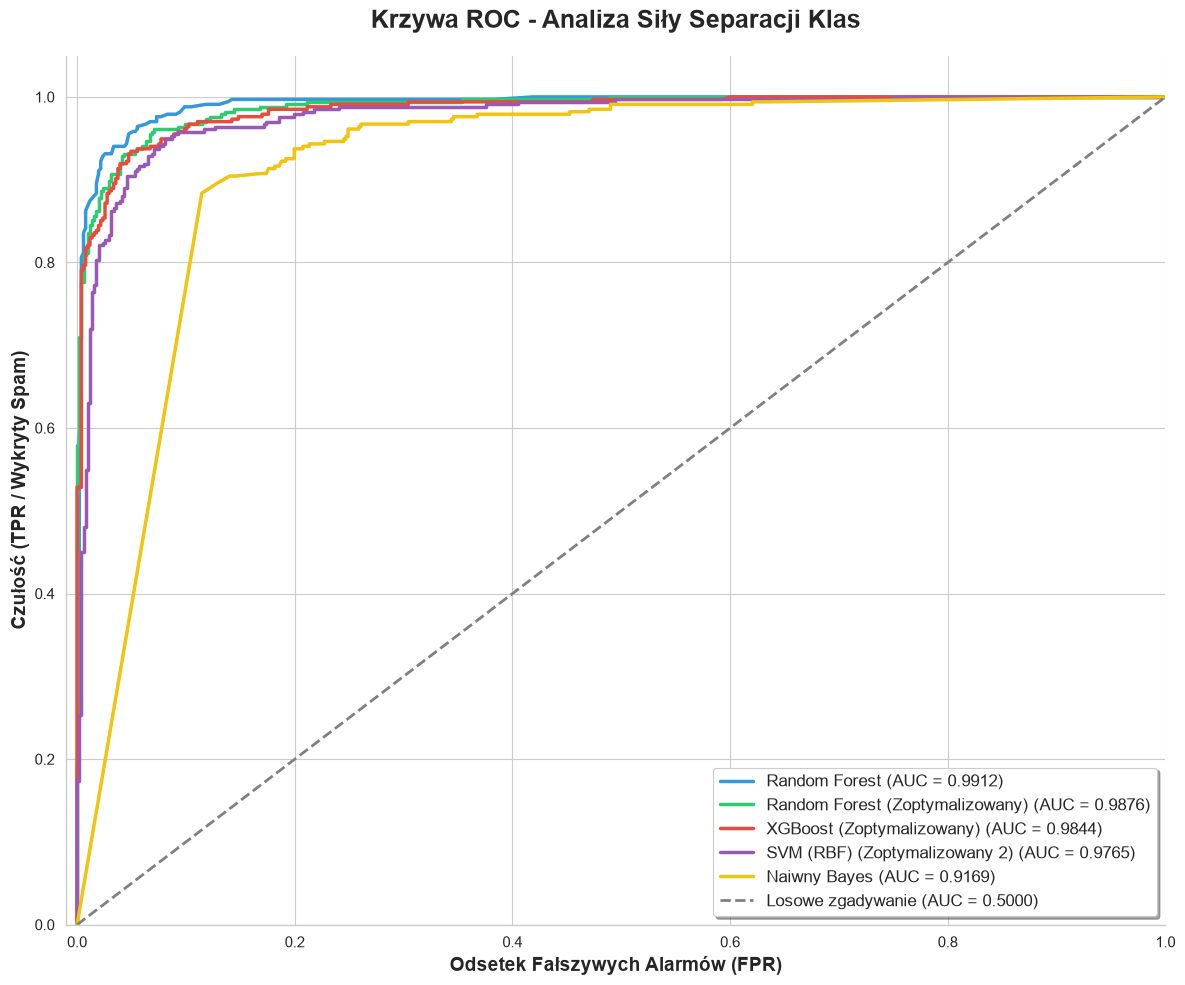

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

print("Kalkulacja krzywych ROC i obszaru AUC...")

# 1. Konfiguracja wykresu
plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 2. Wybieramy kluczowe modele do porównania
kluczowe_modele = [
    "Random Forest", 
    "Random Forest (Zoptymalizowany)", 
    "XGBoost (Zoptymalizowany)", 
    "SVM (RBF) (Zoptymalizowany 2)",
    "Naiwny Bayes" 
]

# Paleta kolorów dla wybranych modeli
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f1c40f']

# 3. Rysowanie krzywych w pętli
for name, color in zip(kluczowe_modele, colors):
    if name in loaded_models:
        model = loaded_models[name]
        
        # Ekstrakcja prawdopodobieństw
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            # Dla modeli bez predict_proba (np. klasyczny SVM Linear)
            y_prob = model.decision_function(X_test)
            
        # Obliczanie FPR, TPR i progu
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        
        # Rysowanie linii dla modelu
        plt.plot(fpr, tpr, color=color, lw=2.5, 
                 label=f'{name} (AUC = {roc_auc:.4f})')

# 4. Dodanie linii odniesienia (losowe zgadywanie)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', 
         label='Losowe zgadywanie (AUC = 0.5000)')

# 5. Formatowanie osi i legendy
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Odsetek Fałszywych Alarmów (FPR)', fontsize=14, fontweight='bold')
plt.ylabel('Czułość (TPR / Wykryty Spam)', fontsize=14, fontweight='bold')
plt.title('Krzywa ROC - Analiza Siły Separacji Klas', fontsize=18, fontweight='bold', pad=20)

plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
sns.despine()

# 6. Zapis i wyświetlenie
plt.tight_layout()
plt.savefig('09_krzywa_roc.png', dpi=300, bbox_inches='tight')
plt.show()

In [56]:
import joblib

print("Wczytywanie modeli XGBoost...\n")

# 1. Wczytanie modeli z dysku
xgb_base = joblib.load("../models/xgboost_cv.pkl")
xgb_tuned = joblib.load("../models/xgboost_tuned.pkl")

# 2. Pobranie pełnych słowników z ustawieniami
params_base = xgb_base.get_params()
params_tuned = xgb_tuned.get_params()

# 3. Lista kluczowych parametrów (filtrujemy techniczny szum)
key_params = [
    'n_estimators',     # Liczba drzew w zespole
    'max_depth',        # Maksymalna głębokość pojedynczego drzewa
    'learning_rate',    # Szybkość uczenia (krok uczenia / eta)
    'subsample',        # Odsetek wierszy losowanych do budowy drzewa
    'colsample_bytree', # Odsetek kolumn (cech) losowanych do budowy drzewa
    'reg_lambda',       # Regularyzacja L2 (kary za zbyt duże wagi w liściach)
    'reg_alpha'         # Regularyzacja L1 (wymusza zerowanie mniej ważnych wag)
]

# 4. Wyświetlenie tabeli porównawczej
print("=== PORÓWNANIE HIPERPARAMETRÓW XGBOOST ===")
print(f"{'Parametr':<20} | {'Model Bazowy':<20} | {'Zoptymalizowany'}")
print("-" * 65)

for p in key_params:
    val_base = params_base.get(p, 'Brak/Domyślne')
    val_tuned = params_tuned.get(p, 'Brak/Domyślne')
    
    # Formatowanie wyświetlania
    val_base_str = str(val_base) if val_base is not None else "Brak"
    val_tuned_str = str(val_tuned) if val_tuned is not None else "Brak"
    
    print(f"{p:<20} | {val_base_str:<20} | {val_tuned_str}")

print("-" * 65)

Wczytywanie modeli XGBoost...

=== PORÓWNANIE HIPERPARAMETRÓW XGBOOST ===
Parametr             | Model Bazowy         | Zoptymalizowany
-----------------------------------------------------------------
n_estimators         | 100                  | 100
max_depth            | 6                    | 7
learning_rate        | 0.1                  | 0.01
subsample            | Brak                 | 0.8
colsample_bytree     | Brak                 | 0.7
reg_lambda           | Brak                 | Brak
reg_alpha            | Brak                 | Brak
-----------------------------------------------------------------


Radykalne spowolnienie uczenia (Learning Rate)

To najważniejsza zmiana w całym zestawieniu. Krok uczenia spadł drastycznie z 0.1 na zaledwie 0.01.

    W praktyce oznacza to, że każde kolejne drzewo w zespole ma tylko drobny wpływ na ostateczny błąd do poprawy.

    Zoptymalizowany model przestał wyciągać pochopne wnioski i zaczął bardzo powoli, mikroskopijnymi krokami korygować wagi z poprzednich iteracji.

Wymuszona losowość (Subsample i Colsample)

Model bazowy (oznaczony jako Brak, czyli używający wartości domyślnych) pobierał 100% wierszy i 100% kolumn do budowy każdego drzewa. Optymalizator brutalnie włączył mechanizm znany jako Stochastic Gradient Boosting.

    Subsample na poziomie 0.8: Każde drzewo losuje teraz tylko 80% wiadomości ze zbioru treningowego. Zabezpiecza to model przed nauczeniem się specyficznych maili na pamięć.

    Colsample_bytree na poziomie 0.7: Każde drzewo "widzi" tylko 70% dostępnych kolumn. Dzięki temu algorytm nie może w nieskończoność polegać na swoich ulubionych słowach-kluczach (jak słynny symbol dolara czy wykrzyknik). Zmusza to słabsze cechy strukturalne wiadomości do cięższej pracy.

Kontrolowane pogłębienie (Max Depth)

Maksymalna głębokość pojedynczego drzewa wzrosła z 6 na 7. Na pierwszy rzut oka wydaje się to nielogiczne, ponieważ głębsze drzewa oznaczają wyższe ryzyko przeuczenia.

    Zostało to jednak w pełni zrekompensowane przez wspomnianą wcześniej losowość oraz bardzo niski współczynnik uczenia.

    Drzewa mogą być teraz minimalnie bardziej złożone i szukać dłuższych ciągów reguł, ponieważ algorytm tłumi ich indywidualny wpływ na ostateczny werdykt.

Wniosek z tego inżynieryjnego podsumowania jest jasny: potężna skuteczność i bezpieczeństwo klasyfikacji nie wzięły się z brutalnej siły i zapamiętywania danych, ale z rygorystycznego powstrzymywania modelu przed zbyt szybkim podejmowaniem decyzji.

Mając pełną wiedzę o metrykach, rozkładzie prawdopodobieństw i wewnętrznej architekturze naszych modeli, zbliżamy się do finału. Czy chcesz teraz napisać prosty skrypt produkcyjny, w którym wpiszesz przykładowe wartości z klawiatury, a wybrany, zoptymalizowany model w czasie rzeczywistym oceni, czy ta wiadomość to spam?

In [57]:
import joblib

print("Wczytywanie modeli SVM (RBF)...\n")

# 1. Wczytanie modeli
svm_base = joblib.load("../models/svm_rbf_cv.pkl")
svm_tuned = joblib.load("../models/svm_rbf_tuned_safe.pkl")

# 2. Pobranie parametrów
params_base = svm_base.get_params()
params_tuned = svm_tuned.get_params()

# 3. Lista kluczowych hiperparametrów dla SVM
key_params = [
    'C',             # Margines błędu (siła regularyzacji)
    'kernel',        # Rodzaj przekształcenia przestrzeni
    'gamma',         # Zasięg wpływu pojedynczych wektorów wspierających
    'class_weight',  # Wagi klas (ochrona przed dominacją jednej z klas)
    'probability'    # Czy wymuszono kalibrację prawdopodobieństw?
]

# 4. Wyświetlenie tabeli
print("=== PORÓWNANIE HIPERPARAMETRÓW SVM (RBF) ===")
print(f"{'Parametr':<15} | {'Model Bazowy':<20} | {'Zoptymalizowany 2'}")
print("-" * 65)

for p in key_params:
    val_base = params_base.get(p, 'Brak/Domyślne')
    val_tuned = params_tuned.get(p, 'Brak/Domyślne')
    
    val_base_str = str(val_base) if val_base is not None else "Brak"
    val_tuned_str = str(val_tuned) if val_tuned is not None else "Brak"
    
    print(f"{p:<15} | {val_base_str:<20} | {val_tuned_str}")

print("-" * 65)

Wczytywanie modeli SVM (RBF)...

=== PORÓWNANIE HIPERPARAMETRÓW SVM (RBF) ===
Parametr        | Model Bazowy         | Zoptymalizowany 2
-----------------------------------------------------------------
C               | 1.0                  | 1
kernel          | rbf                  | rbf
gamma           | scale                | scale
class_weight    | Brak                 | Brak
probability     | True                 | deprecated
-----------------------------------------------------------------
